# 02c - Chignolin Frozen-CV Target Analysis

This notebook is focused on one default training configuration:
- train one simulator/CV backbone
- freeze it
- evaluate `single_cv` and `linear_combo` decoders for `Tm`, `mfpt`, `log_mfpt_ratio`, and `hlda_evalue`
- inspect the best linear-combination decoder through descriptor and residue attribution




In [1]:
# Requires: pip install -e .

import itertools
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

from course_project.models.cv_tm_predictor import BackboneModel
from course_project.peptide import load_target_table
from course_project.peptide_tm import (
    build_train_val_test_split,
    build_metric_dataset,
    extract_cv_sequences,
    metric_stats_from_train_mutants,
    prediction_stats,
    release_cuda_memory,
    run_sim_epoch,
)
from course_project.plotting import PAPER_COLORS, apply_editorial_style, paper_caption, style_axes
from course_project.utils import resolve_device


apply_editorial_style()




### Config


In [2]:
device = torch.device(resolve_device('cuda'))
force_stage1 = False
print('device:', device)

default_config = {
    'name': 'default_top_2',
    'trial_number': 1,
    'train_mutant_count': 10,
    'val_mutant_count': 15,
    'frames_per_traj': 15000,
    'take_every_kth_frame': 25,
    'hidden_size': 128,
    'sim_learning_rate': 3.09e-5,
    'CVs': 4,
    'token_sizes': (320, 80, 4),
    'transformer_layers': 2,
    'pre_pyramid_layers': 2,
}

print('Default configuration:')
display(pd.DataFrame([default_config]))

base_run_name = 'chignolin_cv_tm_2stage'
num_runs = 1
num_experiments = 1

target_metric_names = ['Tm', 'mfpt', 'log_mfpt_ratio', 'hlda_evalue']
metric_name = 'Tm'

history = 1
heads = 1
linear_cv_decoder = True
dropout = 0.0
batch_size = 64
weight_decay = 1e-5
cls_weight = 0.1
time_lag_steps = 0
time_lag_weight = 0.0
sim_epochs = 20
sim_eval_every = 1

train_mutant_count = int(default_config['train_mutant_count'])
val_mutant_count = int(default_config['val_mutant_count'])
frames_per_traj = int(default_config['frames_per_traj'])
take_every_kth_frame = int(default_config['take_every_kth_frame'])
hidden_size = int(default_config['hidden_size'])
CVs = int(default_config['CVs'])
token_sizes = tuple(default_config['token_sizes'])
transformer_layers = int(default_config['transformer_layers'])
pre_pyramid_layers = int(default_config['pre_pyramid_layers'])
sim_learning_rate = float(default_config['sim_learning_rate'])

print({
    'train_mutant_count': train_mutant_count,
    'val_mutant_count': val_mutant_count,
    'frames_per_traj': frames_per_traj,
    'take_every_kth_frame': take_every_kth_frame,
    'hidden_size': hidden_size,
    'CVs': CVs,
    'token_sizes': token_sizes,
    'transformer_layers': transformer_layers,
    'pre_pyramid_layers': pre_pyramid_layers,
    'sim_learning_rate': sim_learning_rate,
})




device: cuda
Default configuration:


,name,trial_number,train_mutant_count,val_mutant_count,frames_per_traj,take_every_kth_frame,hidden_size,sim_learning_rate,CVs,token_sizes,transformer_layers,pre_pyramid_layers
0,default_top_2,1,10,15,15000,25,128,0.000031,4,"(320, 80, 4)",2,2


{'train_mutant_count': 10, 'val_mutant_count': 15, 'frames_per_traj': 15000, 'take_every_kth_frame': 25, 'hidden_size': 128, 'CVs': 4, 'token_sizes': (320, 80, 4), 'transformer_layers': 2, 'pre_pyramid_layers': 2, 'sim_learning_rate': 3.09e-05}


In [3]:
packed = torch.load('../data/peptide/hlda_trajectories_compact.pt', map_location='cpu', weights_only=False)
x_all = packed.get('x_all', packed.get('x')).float()
time_all = packed.get('time_all', packed.get('time')).long()
offsets = packed.get('offsets', packed.get('traj_offsets')).long()
labels = packed['labels'].long()
mutants = packed['mutants']
uniq_mutants_all = sorted(set(str(m) for m in mutants))
n_feat = int(x_all.shape[1])

print('packed trajectories:', len(offsets) - 1 if len(offsets) == len(labels) + 1 else len(offsets))
print('unique packed mutants:', len(uniq_mutants_all))
print('target metrics:', target_metric_names)

target_df = load_target_table(
    '../data/peptide/Tm.csv',
    '../data/peptide/mfpt_slice_thr0p34_tF0p25_tU0p57.csv',
    '../data/peptide/hlda_evalues_thr0p34_tF0p25_tU0p57.csv',
)
target_mutants = set(target_df['mutant'].astype(str))
missing_target_mutants = sorted(set(uniq_mutants_all) - target_mutants)
uniq_mutants = [m for m in uniq_mutants_all if m in target_mutants]
print('usable mutants with targets:', len(uniq_mutants))
if missing_target_mutants:
    print('dropping mutants missing targets:', missing_target_mutants)
display(target_df.head())





packed trajectories: 76
unique packed mutants: 38
target metrics: ['Tm', 'mfpt', 'log_mfpt_ratio', 'hlda_evalue']
usable mutants with targets: 37
dropping mutants missing targets: ['T7G']


,mutant,Tm,mfpt,mfpt_ratio,log_mfpt_ratio,hlda_evalue
0,WT,407.0,6.252921e+05,1.000000,0.000000,4919.890072
1,D2N,420.0,3.952522e+05,0.632108,-0.458695,6592.658671
2,D2A,394.0,8.198605e+05,1.311164,0.270915,6533.154022
3,Y9E,290.0,4.443935e+04,0.071070,-2.644093,2720.063395
4,T7Q,403.0,1.115225e+06,1.783526,0.578592,7664.947324


### Model


### Train


In [4]:
sim_early_stop_patience = 3

base_results_dir = Path('../results') / base_run_name
base_results_dir.mkdir(parents=True, exist_ok=True)
run_dir = base_results_dir / 'run'
run_dir.mkdir(parents=True, exist_ok=True)
print('base results dir:', base_results_dir)
print('run dir:', run_dir)


def build_pooled_feature_df(metric_dataset, metric_name, summary_type='mean'):
    rows = []
    for item in metric_dataset:
        seq = item['cv_seq'].cpu().numpy()
        pooled = seq.mean(axis=0) if summary_type == 'mean' else np.median(seq, axis=0)
        row = {'mutant': item['mutant'], metric_name: float(item['target_value'])}
        for i, value in enumerate(pooled, start=1):
            row[f'cv_{i}'] = float(value)
        rows.append(row)
    return pd.DataFrame(rows)


def fit_linear_coefficients(train_df, feature_cols, target_col):
    X = train_df[feature_cols].to_numpy(dtype=float)
    y = train_df[target_col].to_numpy(dtype=float)
    X_aug = np.column_stack([np.ones(len(X)), X])
    coef, *_ = np.linalg.lstsq(X_aug, y, rcond=None)
    return coef


def predict_linear_df(df, feature_cols, coef, metric_name):
    X = df[feature_cols].to_numpy(dtype=float)
    X_aug = np.column_stack([np.ones(len(X)), X])
    pred = X_aug @ coef
    out = df[['mutant', metric_name]].copy()
    out[f'pred_{metric_name}'] = pred
    return out


def linear_score_df(df, feature_cols, coef, metric_name):
    X = df[feature_cols].to_numpy(dtype=float)
    weights = coef[1:]
    score = X @ weights
    out = df[['mutant', metric_name]].copy()
    out['score'] = score
    return out

def compact_decoder_detail(detail):
    if not isinstance(detail, str) or 'cv_' not in detail:
        return detail
    cols = [token.strip() for token in detail.split('+')]
    idxs = []
    for col in cols:
        if col.startswith('cv_'):
            try:
                idxs.append(int(col.split('_')[1]))
            except Exception:
                return detail
        else:
            return detail
    return '(' + ', '.join(str(i) for i in idxs) + ')'


def normalize_combo_weights(coef):
    coef = np.asarray(coef, dtype=float)
    if coef.size <= 1:
        return coef.copy()
    out = coef.copy()
    scale = float(np.max(np.abs(out[1:]))) if np.any(np.abs(out[1:]) > 0) else 1.0
    out[1:] = out[1:] / max(scale, 1e-12)
    return out


def format_decoder_formula(payload):
    feature_cols = list(payload.get('feature_cols', []))
    coef = np.asarray(payload.get('coef', []), dtype=float) if payload.get('coef') is not None else np.asarray([])
    if payload.get('decoder') != 'linear_combo' or len(feature_cols) == 0 or coef.size != len(feature_cols) + 1:
        return str(payload.get('decoder_detail', ''))
    coef_norm = normalize_combo_weights(coef)
    terms = []
    for weight, col in zip(coef_norm[1:], feature_cols):
        terms.append(f'{weight:+.2f}*{col}')
    return ' '.join(terms)


def show_decoder_prediction_scatter(payloads, metric_name, title_prefix=''):
    payloads = list(payloads)
    if not payloads:
        return
    for payload in payloads:
        fig, ax = plt.subplots(1, 1, figsize=(5.6, 4.3))
        train_df = payload['train_pred_df'][['mutant', metric_name, f'pred_{metric_name}']].copy()
        val_df = payload['val_pred_df'][['mutant', metric_name, f'pred_{metric_name}']].copy()
        test_df = payload['test_pred_df'][['mutant', metric_name, f'pred_{metric_name}']].copy()

        ax.scatter(train_df[metric_name], train_df[f'pred_{metric_name}'], s=22, alpha=0.18, color=PAPER_COLORS['light'], label='TRAIN')
        ax.scatter(val_df[metric_name], val_df[f'pred_{metric_name}'], s=34, alpha=0.78, color=PAPER_COLORS['orange'], label='VAL')
        ax.scatter(test_df[metric_name], test_df[f'pred_{metric_name}'], s=44, alpha=0.95, color=PAPER_COLORS['blue'], marker='D', label='TEST')
        for _, rr in test_df.iterrows():
            ax.text(rr[metric_name], rr[f'pred_{metric_name}'], str(rr['mutant']), fontsize=7, alpha=0.84, color=PAPER_COLORS['blue'])

        xy_all = pd.concat([
            train_df[[metric_name, f'pred_{metric_name}']],
            val_df[[metric_name, f'pred_{metric_name}']],
            test_df[[metric_name, f'pred_{metric_name}']],
        ], ignore_index=True).to_numpy(dtype=float)
        lo = float(np.nanmin(xy_all))
        hi = float(np.nanmax(xy_all))
        pad = 0.05 * (hi - lo + 1e-8)
        lims = (lo - pad, hi + pad)
        ax.plot(lims, lims, color='#0f172a', linestyle='--', linewidth=1.0)
        ax.set_xlim(lims)
        ax.set_ylim(lims)

        val_stats = payload['val_stats']
        test_stats = payload['test_stats']
        detail = format_decoder_formula(payload) if payload.get('decoder') == 'linear_combo' else str(payload['decoder_detail'])
        prefix = f'{title_prefix} | ' if title_prefix else ''
        print(f'{prefix}{payload["decoder"]}: {detail} | VAL RMSE={val_stats["rmse"]:.2f}, r={val_stats["pearson"]:.3f} | TEST RMSE={test_stats["rmse"]:.2f}, r={test_stats["pearson"]:.3f}')
        style_axes(ax, xlabel=f'true {metric_name}', ylabel=f'predicted {metric_name}', legend=True)
        plt.tight_layout()
        plt.show()


def fit_best_single_cv_decoder(train_df, val_df, test_df, metric_name):
    cv_cols = [c for c in train_df.columns if c.startswith('cv_')]
    candidates = []
    for col in cv_cols:
        coef = fit_linear_coefficients(train_df, [col], metric_name)
        train_pred_df = predict_linear_df(train_df, [col], coef, metric_name)
        val_pred_df = predict_linear_df(val_df, [col], coef, metric_name)
        test_pred_df = predict_linear_df(test_df, [col], coef, metric_name)
        candidates.append({
            'decoder': 'single_cv',
            'decoder_detail': col,
            'feature_cols': [col],
            'coef': coef.tolist(),
            'train_pred_df': train_pred_df,
            'val_pred_df': val_pred_df,
            'test_pred_df': test_pred_df,
            'train_stats': prediction_stats(train_pred_df, metric_name),
            'val_stats': prediction_stats(val_pred_df, metric_name),
            'test_stats': prediction_stats(test_pred_df, metric_name),
        })
    candidates.sort(key=lambda row: (-abs(row['val_stats']['pearson']), row['val_stats']['rmse'], row['val_stats']['mae']))
    return candidates[0]


def fit_linear_combo_decoder(train_df, val_df, test_df, metric_name):
    cv_cols = [c for c in train_df.columns if c.startswith('cv_')]
    best_result = None
    for subset_size in range(1, len(cv_cols) + 1):
        for subset in itertools.combinations(cv_cols, subset_size):
            subset = list(subset)
            coef = fit_linear_coefficients(train_df, subset, metric_name)
            train_pred_df = predict_linear_df(train_df, subset, coef, metric_name)
            val_pred_df = predict_linear_df(val_df, subset, coef, metric_name)
            test_pred_df = predict_linear_df(test_df, subset, coef, metric_name)
            result = {
                'decoder': 'linear_combo',
                'decoder_detail': ' + '.join(subset),
                'feature_cols': subset,
                'coef': coef.tolist(),
                'train_pred_df': train_pred_df,
                'val_pred_df': val_pred_df,
                'test_pred_df': test_pred_df,
                'train_stats': prediction_stats(train_pred_df, metric_name),
                'val_stats': prediction_stats(val_pred_df, metric_name),
                'test_stats': prediction_stats(test_pred_df, metric_name),
            }
            if best_result is None or (abs(result['val_stats']['pearson']), -result['val_stats']['rmse'], -result['val_stats']['mae']) > (abs(best_result['val_stats']['pearson']), -best_result['val_stats']['rmse'], -best_result['val_stats']['mae']):
                best_result = result
    return best_result


def monitor_single_cv_metrics(backbone, split_payload, monitor_metric_names):
    train_cv_sequences = extract_cv_sequences(backbone, split_payload['train_x'], split_payload['train_samples_df'], batch_size=batch_size, device=device)
    val_cv_sequences = extract_cv_sequences(backbone, split_payload['val_x'], split_payload['val_samples_df'], batch_size=batch_size, device=device)
    monitor = {}
    for current_metric_name in monitor_metric_names:
        metric_stats = metric_stats_from_train_mutants(split_payload['train_mutants'], target_df, current_metric_name)
        train_metric_dataset = build_metric_dataset(train_cv_sequences, metric_stats, target_df, current_metric_name)
        val_metric_dataset = build_metric_dataset(val_cv_sequences, metric_stats, target_df, current_metric_name)
        train_pooled_df = build_pooled_feature_df(train_metric_dataset, current_metric_name)
        val_pooled_df = build_pooled_feature_df(val_metric_dataset, current_metric_name)
        empty_test_df = val_pooled_df.copy()
        result = fit_best_single_cv_decoder(train_pooled_df, val_pooled_df, empty_test_df, current_metric_name)
        metric_prefix = current_metric_name.lower().replace('/', '_')
        monitor[f'{metric_prefix}_best_cv'] = str(result['decoder_detail'])
        monitor[f'{metric_prefix}_val_pearson'] = float(result['val_stats']['pearson'])
        monitor[f'{metric_prefix}_val_rmse'] = float(result['val_stats']['rmse'])
    return monitor


stage1_monitor_metric_names = ['Tm', 'hlda_evalue']

cfg = {
    'history': history,
    'frames_per_traj': frames_per_traj,
    'take_every_kth_frame': take_every_kth_frame,
    'hidden_size': hidden_size,
    'CVs': int(token_sizes[-1]),
    'token_sizes': tuple(token_sizes),
    'heads': heads,
    'transformer_layers': transformer_layers,
    'pre_pyramid_layers': pre_pyramid_layers,
    'linear_cv_decoder': linear_cv_decoder,
    'dropout': dropout,
    'batch_size': batch_size,
    'weight_decay': weight_decay,
    'cls_weight': cls_weight,
    'time_lag_steps': time_lag_steps,
    'time_lag_weight': time_lag_weight,
    'sim_learning_rate': sim_learning_rate,
    'sim_epochs': sim_epochs,
    'sim_eval_every': sim_eval_every,
    'sim_early_stop_patience': sim_early_stop_patience,
    'metric_name': metric_name,
    'stage1_monitor_metric_names': list(stage1_monitor_metric_names),
}
print(json.dumps({k: (list(v) if isinstance(v, tuple) else v) for k, v in cfg.items() if k in ['frames_per_traj', 'take_every_kth_frame', 'hidden_size', 'CVs', 'token_sizes', 'transformer_layers', 'pre_pyramid_layers', 'batch_size', 'cls_weight']}, indent=2))

sim_history_csv = run_dir / 'sim_history.csv'
run_summary_csv = run_dir / 'run_summary.csv'
config_json = run_dir / 'config.json'
expected_backbone_ckpts = [run_dir / f'run_{run_idx:02d}_backbone.pt' for run_idx in range(1, num_runs + 1)]
need_stage1 = force_stage1 or not sim_history_csv.exists() or not run_summary_csv.exists() or any(not p.exists() for p in expected_backbone_ckpts)
stage1_was_retrained = bool(need_stage1)

if need_stage1:
    sim_history_rows = []
    run_rows = []
    for run_idx in [1]:
        backbone_ckpt = run_dir / f'run_{run_idx:02d}_backbone.pt'
        run_seed = int(torch.seed() % (2**32 - 1))
        random.seed(run_seed)
        np.random.seed(run_seed)
        torch.manual_seed(run_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(run_seed)

        split_payload = build_train_val_test_split(
            run_seed=run_seed,
            uniq_mutants=uniq_mutants,
            train_mutant_count=train_mutant_count,
            val_mutant_count=val_mutant_count,
            mutants=mutants,
            history=cfg['history'],
            time_lag_steps=cfg['time_lag_steps'],
            frames_per_traj=cfg['frames_per_traj'],
            take_every_kth_frame=cfg['take_every_kth_frame'],
            x_all=x_all,
            time_all=time_all,
            offsets=offsets,
            labels=labels,
            n_feat=n_feat,
        )

        release_cuda_memory()
        backbone = BackboneModel(
            feat_dim=n_feat,
            history=cfg['history'],
            hidden=cfg['hidden_size'],
            token_sizes=cfg['token_sizes'],
            heads=cfg['heads'],
            token_layers=cfg['transformer_layers'],
            dropout=cfg['dropout'],
            pre_pyramid_layers=cfg['pre_pyramid_layers'],
            linear_cv_decoder=cfg['linear_cv_decoder'],
        ).to(device)
        sim_opt = torch.optim.AdamW(backbone.parameters(), lr=cfg['sim_learning_rate'], weight_decay=cfg['weight_decay'])
        train_loader = DataLoader(TensorDataset(split_payload['train_x'], split_payload['train_dv'], split_payload['train_dv_tau'], split_payload['train_cls']), batch_size=cfg['batch_size'], shuffle=True, drop_last=False)
        val_loader = DataLoader(TensorDataset(split_payload['val_x'], split_payload['val_dv'], split_payload['val_dv_tau'], split_payload['val_cls']), batch_size=cfg['batch_size'], shuffle=False, drop_last=False)

        best_sim_loss = float('inf')
        best_sim_epoch = 0
        sim_bad_epochs = 0
        for epoch in range(1, cfg['sim_epochs'] + 1):
            tr = run_sim_epoch(backbone, train_loader, device=device, time_lag_steps=cfg['time_lag_steps'], time_lag_weight=cfg['time_lag_weight'], cls_weight=cfg['cls_weight'], opt=sim_opt)
            va = run_sim_epoch(backbone, val_loader, device=device, time_lag_steps=cfg['time_lag_steps'], time_lag_weight=cfg['time_lag_weight'], cls_weight=cfg['cls_weight'], opt=None)
            monitor_row = {}
            should_monitor = (epoch == 1) or (epoch == cfg['sim_epochs']) or (epoch % cfg['sim_eval_every'] == 0)
            if should_monitor:
                backbone.eval()
                with torch.no_grad():
                    monitor_row = monitor_single_cv_metrics(backbone, split_payload, cfg['stage1_monitor_metric_names'])
            sim_history_rows.append({'run_idx': run_idx, 'run_seed': run_seed, 'epoch': epoch, **{f'train_{k}': v for k, v in tr.items()}, **{f'val_{k}': v for k, v in va.items()}, **monitor_row})
            if va['sim_loss'] < best_sim_loss - 1e-8:
                best_sim_loss = va['sim_loss']
                best_sim_epoch = epoch
                sim_bad_epochs = 0
                torch.save({'run_idx': run_idx, 'run_seed': run_seed, 'epoch': epoch, 'model_state_dict': backbone.state_dict()}, backbone_ckpt)
            else:
                sim_bad_epochs += 1
            if should_monitor:
                tm_r = monitor_row.get('tm_val_pearson', float('nan'))
                tm_rmse = monitor_row.get('tm_val_rmse', float('nan'))
                eig_r = monitor_row.get('hlda_evalue_val_pearson', float('nan'))
                eig_rmse = monitor_row.get('hlda_evalue_val_rmse', float('nan'))
                print(
                    f'stage1 run {run_idx:02d} epoch {epoch:03d} | train sim={tr["sim_loss"]:.4f} | val sim={va["sim_loss"]:.4f} | '
                    f'Tm r={tm_r:.3f} rmse={tm_rmse:.2f} | EV r={eig_r:.3f} rmse={eig_rmse:.2f} | '
                    f'best={best_sim_loss:.4f} bad={sim_bad_epochs}/{cfg["sim_early_stop_patience"]}'
                )
            if sim_bad_epochs >= cfg['sim_early_stop_patience']:
                print(f'stage1 run {run_idx:02d} early stop at epoch {epoch:03d} | best epoch={best_sim_epoch:03d} val sim={best_sim_loss:.4f}')
                break

        run_rows.append({
            'run_idx': run_idx,
            'run_seed': run_seed,
            'sim_final_epoch': epoch,
            'best_sim_epoch': best_sim_epoch,
            'train_mutants': len(split_payload['train_mutants']),
            'val_mutants': len(split_payload['val_mutants']),
            'test_mutants': len(split_payload['test_mutants']),
        })
        release_cuda_memory()

    sim_history_df = pd.DataFrame(sim_history_rows)
    run_summary_df = pd.DataFrame(run_rows)
    sim_history_df.to_csv(sim_history_csv, index=False)
    run_summary_df.to_csv(run_summary_csv, index=False)
    config_json.write_text(json.dumps({**cfg, 'token_sizes': list(cfg['token_sizes']), 'val_mutant_count': val_mutant_count}, indent=2))
else:
    sim_history_df = pd.read_csv(sim_history_csv)
    run_summary_df = pd.read_csv(run_summary_csv)

print('stage1 run summary:')
run_summary_df






base results dir: ../results/chignolin_cv_tm_2stage
run dir: ../results/chignolin_cv_tm_2stage/run
{
  "frames_per_traj": 15000,
  "take_every_kth_frame": 25,
  "hidden_size": 128,
  "CVs": 4,
  "token_sizes": [
    320,
    80,
    4
  ],
  "transformer_layers": 2,
  "pre_pyramid_layers": 2,
  "batch_size": 64,
  "cls_weight": 0.1
}
stage1 run summary:


,run_idx,run_seed,sim_final_epoch,best_sim_epoch,train_mutants,val_mutants,test_mutants,selected_decoder_Tm,selected_decoder_detail_Tm,selected_decoder_mfpt,selected_decoder_detail_mfpt,selected_decoder_log_mfpt_ratio,selected_decoder_detail_log_mfpt_ratio,selected_decoder_hlda_evalue,selected_decoder_detail_hlda_evalue
0,1,2600223659,17,14,10,15,12,linear_combo,"(3, 4)",single_cv,(2),single_cv,(1),single_cv,(3)


In [5]:
base_results_dir = Path('../results') / base_run_name
run_dir = base_results_dir / 'run'
print('run dir:', run_dir)

cfg = {
    'history': history,
    'frames_per_traj': frames_per_traj,
    'take_every_kth_frame': take_every_kth_frame,
    'hidden_size': hidden_size,
    'CVs': int(token_sizes[-1]),
    'token_sizes': tuple(token_sizes),
    'heads': heads,
    'transformer_layers': transformer_layers,
    'pre_pyramid_layers': pre_pyramid_layers,
    'linear_cv_decoder': linear_cv_decoder,
    'dropout': dropout,
    'batch_size': batch_size,
    'weight_decay': weight_decay,
    'cls_weight': cls_weight,
    'time_lag_steps': time_lag_steps,
    'time_lag_weight': time_lag_weight,
}
print(json.dumps({k: (list(v) if isinstance(v, tuple) else v) for k, v in cfg.items() if k in ['hidden_size', 'CVs', 'token_sizes', 'frames_per_traj', 'take_every_kth_frame']}, indent=2))

sim_history_csv = run_dir / 'sim_history.csv'
run_summary_csv = run_dir / 'run_summary.csv'
pred_summary_csv = run_dir / 'metric_prediction_summary.csv'
need_stage2 = stage1_was_retrained or (not pred_summary_csv.exists())
if pred_summary_csv.exists():
    existing_pred_summary_df = pd.read_csv(pred_summary_csv)
    existing_decoders = set(existing_pred_summary_df['decoder'].astype(str)) if 'decoder' in existing_pred_summary_df.columns else set()
    existing_metrics = set(existing_pred_summary_df['metric'].astype(str)) if 'metric' in existing_pred_summary_df.columns else set()
    if existing_decoders - {'single_cv', 'linear_combo'}:
        need_stage2 = True
    if set(target_metric_names) - existing_metrics:
        need_stage2 = True
print('stage2 recompute:', need_stage2)

sim_history_df = pd.read_csv(sim_history_csv)
run_summary_df = pd.read_csv(run_summary_csv)
pred_rows = []
trained_payloads = []

if need_stage2:
    for _, run_row in run_summary_df.iloc[:1].iterrows():
        run_idx = int(run_row['run_idx'])
        run_seed = int(run_row['run_seed'])
        backbone_ckpt = run_dir / f'run_{run_idx:02d}_backbone.pt'

        split_payload = build_train_val_test_split(
            run_seed=run_seed,
            uniq_mutants=uniq_mutants,
            train_mutant_count=train_mutant_count,
            val_mutant_count=val_mutant_count,
            mutants=mutants,
            history=cfg['history'],
            time_lag_steps=cfg['time_lag_steps'],
            frames_per_traj=cfg['frames_per_traj'],
            take_every_kth_frame=cfg['take_every_kth_frame'],
            x_all=x_all,
            time_all=time_all,
            offsets=offsets,
            labels=labels,
            n_feat=n_feat,
        )

        release_cuda_memory()
        backbone = BackboneModel(
            feat_dim=n_feat,
            history=cfg['history'],
            hidden=cfg['hidden_size'],
            token_sizes=cfg['token_sizes'],
            heads=cfg['heads'],
            token_layers=cfg['transformer_layers'],
            dropout=cfg['dropout'],
            pre_pyramid_layers=cfg['pre_pyramid_layers'],
            linear_cv_decoder=cfg['linear_cv_decoder'],
        ).to(device)
        backbone.load_state_dict(torch.load(backbone_ckpt, map_location='cpu', weights_only=False)['model_state_dict'])
        backbone.eval()

        train_cv_sequences = extract_cv_sequences(backbone, split_payload['train_x'], split_payload['train_samples_df'], batch_size=cfg['batch_size'], device=device)
        val_cv_sequences = extract_cv_sequences(backbone, split_payload['val_x'], split_payload['val_samples_df'], batch_size=cfg['batch_size'], device=device)
        test_cv_sequences = extract_cv_sequences(backbone, split_payload['test_x'], split_payload['test_samples_df'], batch_size=cfg['batch_size'], device=device)

        for current_metric_name in target_metric_names:
            metric_stats = metric_stats_from_train_mutants(split_payload['train_mutants'], target_df, current_metric_name)
            train_metric_dataset = build_metric_dataset(train_cv_sequences, metric_stats, target_df, current_metric_name)
            val_metric_dataset = build_metric_dataset(val_cv_sequences, metric_stats, target_df, current_metric_name)
            test_metric_dataset = build_metric_dataset(test_cv_sequences, metric_stats, target_df, current_metric_name)
            train_pooled_df = build_pooled_feature_df(train_metric_dataset, current_metric_name)
            val_pooled_df = build_pooled_feature_df(val_metric_dataset, current_metric_name)
            test_pooled_df = build_pooled_feature_df(test_metric_dataset, current_metric_name)

            decoder_results = [
                fit_best_single_cv_decoder(train_pooled_df, val_pooled_df, test_pooled_df, current_metric_name),
                fit_linear_combo_decoder(train_pooled_df, val_pooled_df, test_pooled_df, current_metric_name),
            ]

            best_decoder_result = sorted(decoder_results, key=lambda row: (row['val_stats']['rmse'], row['val_stats']['mae'], -row['val_stats']['r2']))[0]
            run_summary_df.loc[run_summary_df['run_idx'] == run_idx, f'selected_decoder_{current_metric_name}'] = best_decoder_result['decoder']
            run_summary_df.loc[run_summary_df['run_idx'] == run_idx, f'selected_decoder_detail_{current_metric_name}'] = compact_decoder_detail(best_decoder_result['decoder_detail'])

            safe_metric_name = current_metric_name.replace('/', '_')
            for result in decoder_results:
                decoder = result['decoder']
                decoder_detail = result['decoder_detail']
                train_pred_df = result['train_pred_df']
                val_pred_df = result['val_pred_df']
                test_pred_df = result['test_pred_df']
                train_pred_df.to_csv(run_dir / f'run_{run_idx:02d}_{safe_metric_name}_{decoder}_train_predictions.csv', index=False)
                val_pred_df.to_csv(run_dir / f'run_{run_idx:02d}_{safe_metric_name}_{decoder}_val_predictions.csv', index=False)
                test_pred_df.to_csv(run_dir / f'run_{run_idx:02d}_{safe_metric_name}_{decoder}_test_predictions.csv', index=False)
                pred_rows.append({
                    'run_idx': run_idx,
                    'run_seed': run_seed,
                    'decoder': decoder,
                    'decoder_detail': decoder_detail,
                    'feature_cols': json.dumps(result.get('feature_cols', [])),
                    'coef': json.dumps(result.get('coef', [])),
                    'metric': current_metric_name,
                    **{f'train_{k}': v for k, v in result['train_stats'].items()},
                    **{f'val_{k}': v for k, v in result['val_stats'].items()},
                    **{f'test_{k}': v for k, v in result['test_stats'].items()},
                })
                trained_payloads.append({
                    'run_idx': run_idx,
                    'run_seed': run_seed,
                    'metric': current_metric_name,
                    'decoder': decoder,
                    'decoder_detail': decoder_detail,
                    'feature_cols': result.get('feature_cols', []),
                    'coef': result.get('coef', []),
                    'train_pred_df': train_pred_df,
                    'val_pred_df': val_pred_df,
                    'test_pred_df': test_pred_df,
                    'train_stats': result['train_stats'],
                    'val_stats': result['val_stats'],
                    'test_stats': result['test_stats'],
                })

            run_decoder_rows_df = pd.DataFrame([{
                'metric': current_metric_name,
                'decoder': result['decoder'],
                'decoder_detail': result['decoder_detail'],
                'val_rmse': result['val_stats']['rmse'],
                'val_pearson': result['val_stats']['pearson'],
                'val_spearman': result['val_stats']['spearman'],
                'test_rmse': result['test_stats']['rmse'],
                'test_pearson': result['test_stats']['pearson'],
                'test_spearman': result['test_stats']['spearman'],
            } for result in decoder_results]).sort_values(['val_rmse', 'test_rmse']).reset_index(drop=True)
            print(f'decoder results for the trained run | {current_metric_name}:')
            display(run_decoder_rows_df.round(4))
            run_metric_payloads = [payload for payload in trained_payloads if int(payload['run_idx']) == run_idx and payload['metric'] == current_metric_name]
            show_decoder_prediction_scatter(sorted(run_metric_payloads, key=lambda p: p['decoder']), current_metric_name)

    metric_prediction_summary_df = pd.DataFrame(pred_rows)
    run_summary_df.to_csv(run_summary_csv, index=False)
    metric_prediction_summary_df.to_csv(pred_summary_csv, index=False)
else:
    metric_prediction_summary_df = pd.read_csv(pred_summary_csv)
    trained_payloads = []
    for _, row in metric_prediction_summary_df.iterrows():
        run_idx = int(row['run_idx'])
        decoder = str(row['decoder'])
        current_metric_name = str(row['metric'])
        safe_metric_name = current_metric_name.replace('/', '_')
        train_pred_df = pd.read_csv(run_dir / f'run_{run_idx:02d}_{safe_metric_name}_{decoder}_train_predictions.csv')
        val_pred_df = pd.read_csv(run_dir / f'run_{run_idx:02d}_{safe_metric_name}_{decoder}_val_predictions.csv')
        test_pred_df = pd.read_csv(run_dir / f'run_{run_idx:02d}_{safe_metric_name}_{decoder}_test_predictions.csv')
        run_seed = int(run_summary_df.loc[run_summary_df['run_idx'] == run_idx, 'run_seed'].iloc[0])
        trained_payloads.append({
            'run_idx': run_idx,
            'run_seed': run_seed,
            'metric': current_metric_name,
            'decoder': decoder,
            'decoder_detail': row.get('decoder_detail', ''),
            'feature_cols': json.loads(row['feature_cols']) if 'feature_cols' in row.index and pd.notna(row['feature_cols']) else [],
            'coef': json.loads(row['coef']) if 'coef' in row.index and pd.notna(row['coef']) else [],
            'train_pred_df': train_pred_df,
            'val_pred_df': val_pred_df,
            'test_pred_df': test_pred_df,
            'train_stats': {k.replace('train_', ''): row[k] for k in row.index if str(k).startswith('train_')},
            'val_stats': {k.replace('val_', ''): row[k] for k in row.index if str(k).startswith('val_')},
            'test_stats': {k.replace('test_', ''): row[k] for k in row.index if str(k).startswith('test_')},
        })

best_metric_prediction_summary_df = metric_prediction_summary_df.sort_values(['metric', 'val_rmse', 'val_mae', 'val_r2'], ascending=[True, True, True, False]).groupby(['run_idx', 'metric'], as_index=False).head(1).reset_index(drop=True)
best_keys = {(int(row['run_idx']), str(row['metric']), str(row['decoder'])) for _, row in best_metric_prediction_summary_df.iterrows()}
all_trained_payloads = list(trained_payloads)
trained_payloads = [payload for payload in trained_payloads if (int(payload['run_idx']), str(payload['metric']), str(payload['decoder'])) in best_keys]
selected_payloads_by_metric = {payload['metric']: payload for payload in trained_payloads}
print('selected decoder rows:')
display(best_metric_prediction_summary_df.round(3))




run dir: ../results/chignolin_cv_tm_2stage/run
{
  "frames_per_traj": 15000,
  "take_every_kth_frame": 25,
  "hidden_size": 128,
  "CVs": 4,
  "token_sizes": [
    320,
    80,
    4
  ]
}
stage2 recompute: False
selected decoder rows:


,run_idx,run_seed,decoder,decoder_detail,feature_cols,coef,metric,train_n,train_rmse,train_mae,...,val_spearman,val_spearman_p,test_n,test_rmse,test_mae,test_r2,test_pearson,test_pearson_p,test_spearman,test_spearman_p
0,1,2600223659,linear_combo,cv_3 + cv_4,"[""cv_3"", ""cv_4""]","[400.1655105760038, -190.0562506748476, -21.49...",Tm,10,18.135,15.786,...,0.457,0.087,12,30.840,24.103,0.560,0.701,0.011,0.727,0.007
1,1,2600223659,single_cv,cv_3,"[""cv_3""]","[5755.276724273874, -5444.424115000816]",hlda_evalue,10,1545.918,1335.291,...,0.232,0.405,12,1361.058,1003.226,0.310,0.388,0.213,0.385,0.217
2,1,2600223659,single_cv,cv_1,"[""cv_1""]","[0.31806664417923064, -3.9346562897380317]",log_mfpt_ratio,10,1.311,1.130,...,-0.196,0.483,12,1.933,1.612,-0.105,0.479,0.115,0.315,0.319
3,1,2600223659,single_cv,cv_2,"[""cv_2""]","[5696997.907261952, -22745044.275257695]",mfpt,10,4627460.832,3440110.282,...,-0.232,0.405,12,2345781.305,1891096.328,-1.942,-0.255,0.423,-0.280,0.379


### Evaluation


Stage-1 simulator loss over training epochs


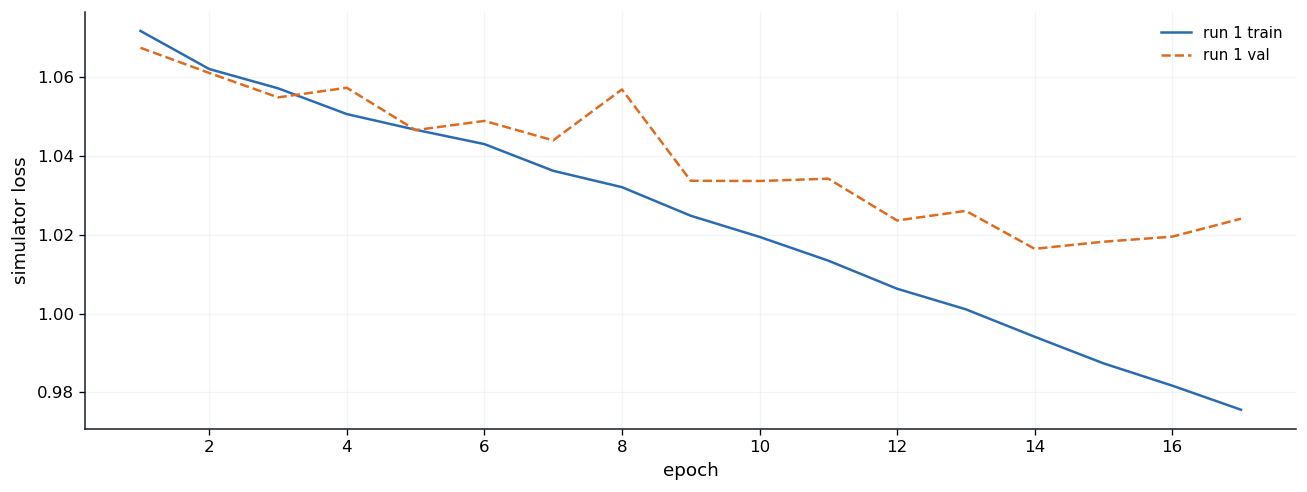

In [6]:
paper_caption('Stage-1 simulator loss over training epochs')
fig, ax = plt.subplots(1, 1, figsize=(11, 4.2))
for run_idx, sub in sim_history_df.groupby('run_idx'):
    sub = sub.sort_values('epoch')
    ax.plot(sub['epoch'], sub['train_sim_loss'], color='#2b6cb0', lw=1.5, label=f'run {run_idx} train')
    ax.plot(sub['epoch'], sub['val_sim_loss'], color='#dd6b20', lw=1.5, ls='--', label=f'run {run_idx} val')
style_axes(ax, xlabel='epoch', ylabel='simulator loss', legend=True)
plt.tight_layout()
plt.show()



Decoder prediction scatter for Tm
linear_combo: -1.00*cv_3 -0.11*cv_4 | VAL RMSE=39.28, r=0.484 | TEST RMSE=30.84, r=0.701


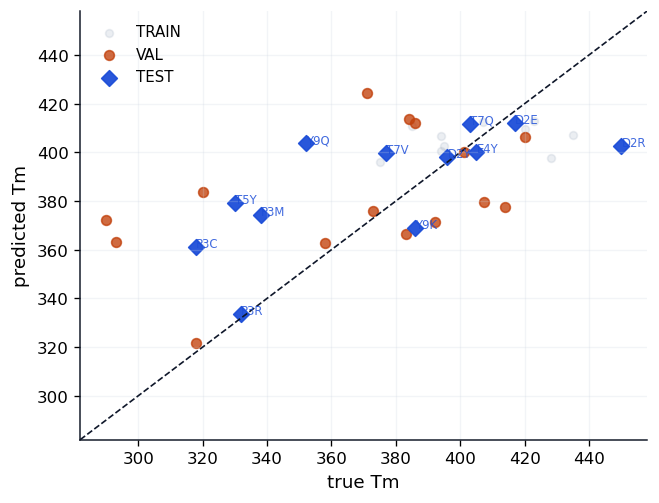

single_cv: cv_3 | VAL RMSE=39.96, r=0.468 | TEST RMSE=32.27, r=0.680


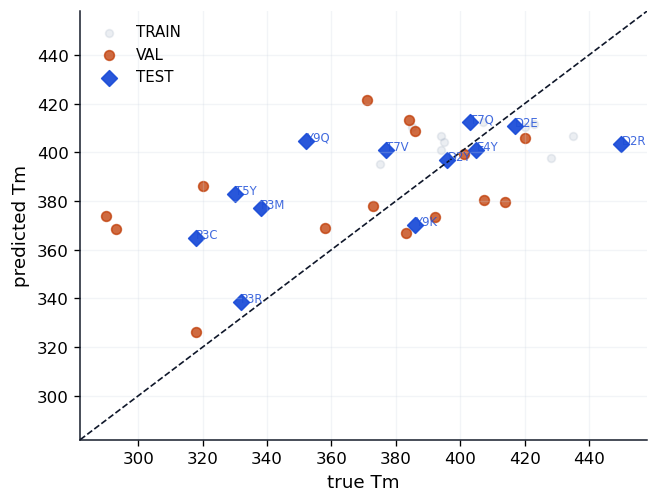

Decoder prediction scatter for mfpt
linear_combo: -1.00*cv_2 | VAL RMSE=3590237.58, r=0.116 | TEST RMSE=2345781.30, r=-0.255


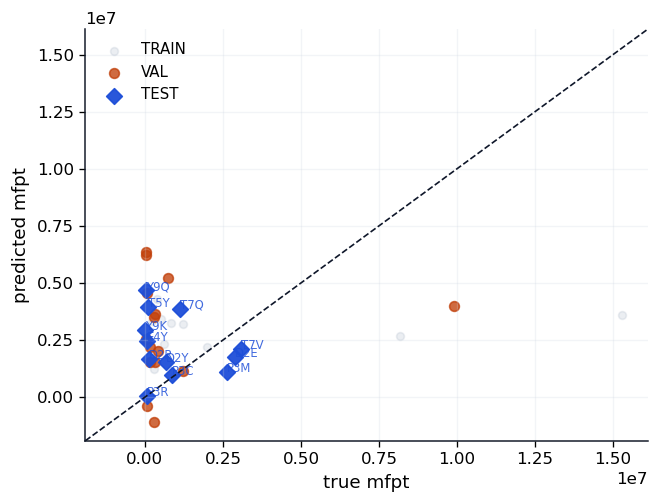

single_cv: cv_2 | VAL RMSE=3590237.58, r=0.116 | TEST RMSE=2345781.30, r=-0.255


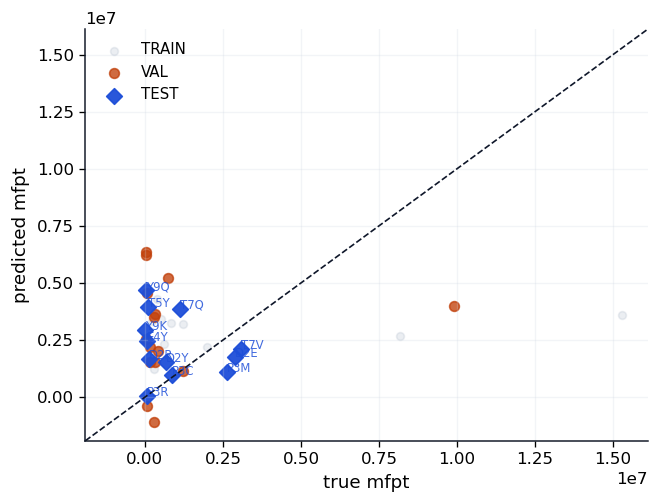

Decoder prediction scatter for log_mfpt_ratio
linear_combo: +0.10*cv_1 +0.38*cv_2 +1.00*cv_3 +0.85*cv_4 | VAL RMSE=4.62, r=-0.326 | TEST RMSE=4.95, r=-0.202


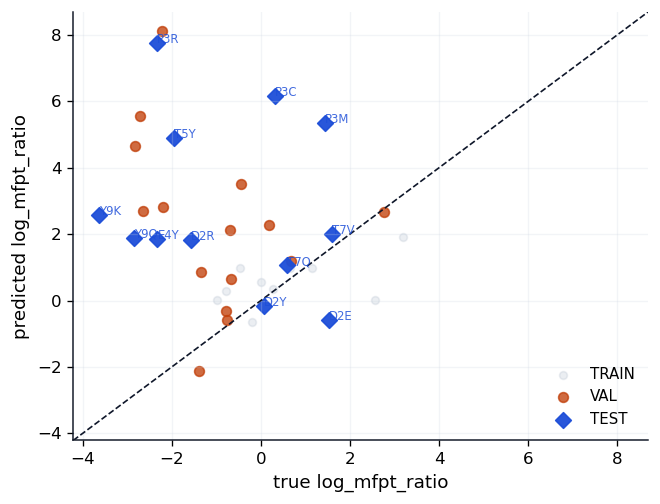

single_cv: cv_1 | VAL RMSE=2.20, r=-0.213 | TEST RMSE=1.93, r=0.479


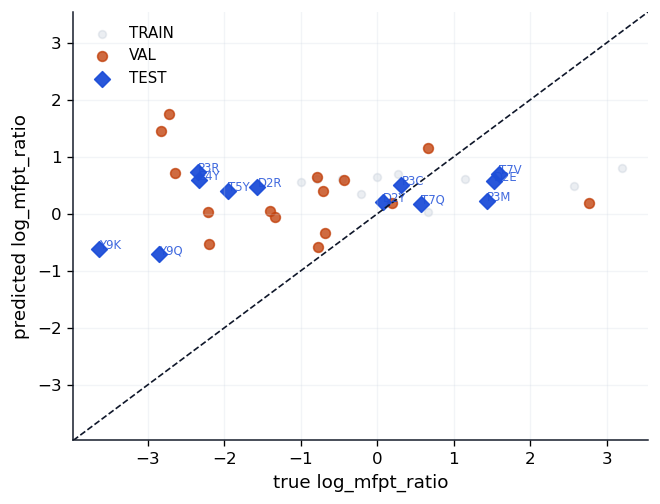

Decoder prediction scatter for hlda_evalue
linear_combo: -1.00*cv_3 | VAL RMSE=1766.08, r=0.176 | TEST RMSE=1361.06, r=0.388


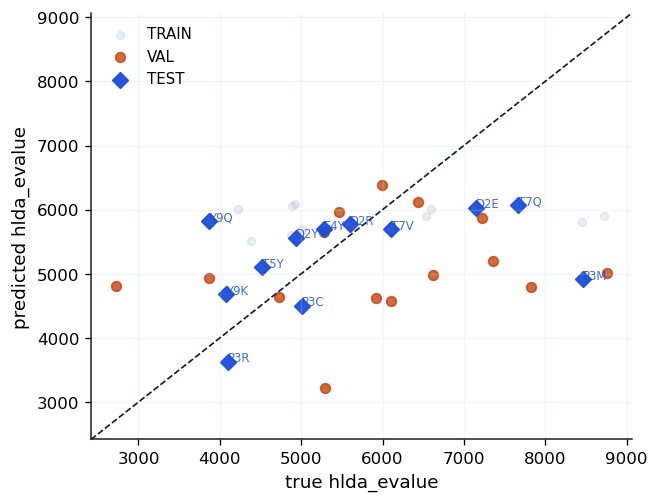

single_cv: cv_3 | VAL RMSE=1766.08, r=0.176 | TEST RMSE=1361.06, r=0.388


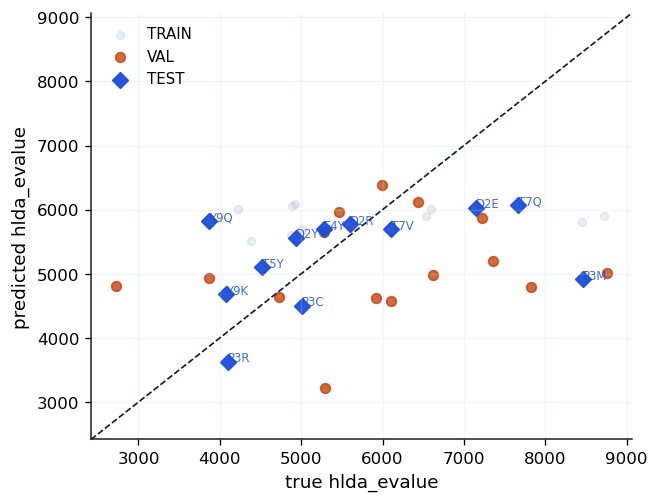

In [7]:
# Decoder comparison predicted-target scatter plots for the single trained run.
for current_metric_name in target_metric_names:
    paper_caption(f'Decoder prediction scatter for {current_metric_name}')
    comparison_payloads = sorted(
        [p for p in all_trained_payloads if p['metric'] == current_metric_name],
        key=lambda p: (p['run_idx'], p['decoder'])
    )
    show_decoder_prediction_scatter(comparison_payloads, current_metric_name)





In [8]:
print('decoder results:')
display_cols = [
    'metric', 'run_idx', 'run_seed', 'decoder', 'decoder_detail',
    'train_n', 'train_rmse', 'train_mae', 'train_r2',
    'val_n', 'val_rmse', 'val_mae', 'val_r2', 'val_pearson', 'val_spearman', 'val_pearson_p', 'val_spearman_p',
    'test_n', 'test_rmse', 'test_mae', 'test_r2', 'test_pearson', 'test_spearman', 'test_pearson_p', 'test_spearman_p',
]
decoder_results_df = metric_prediction_summary_df[display_cols].copy()
decoder_results_df['decoder_detail'] = decoder_results_df['decoder_detail'].map(compact_decoder_detail)
decoder_results_df = decoder_results_df.sort_values(
    ['metric', 'val_rmse', 'val_mae', 'val_r2'],
    ascending=[True, True, True, False],
).reset_index(drop=True)
display(decoder_results_df.round(3))

for current_metric_name in target_metric_names:
    current_linear_combo_df = metric_prediction_summary_df[
        (metric_prediction_summary_df['metric'].astype(str) == current_metric_name) &
        (metric_prediction_summary_df['decoder'].astype(str) == 'linear_combo')
    ].copy().sort_values('run_idx').reset_index(drop=True)
    current_linear_combo_df['decoder_detail'] = current_linear_combo_df['decoder_detail'].map(compact_decoder_detail)
    print(f'single-run linear_combo summary | {current_metric_name}:')
    display(current_linear_combo_df[[
        'run_idx', 'run_seed', 'decoder_detail',
        'val_rmse', 'val_pearson', 'val_spearman',
        'test_rmse', 'test_pearson', 'test_spearman',
        'test_pearson_p', 'test_spearman_p',
    ]].round(4))



decoder results:


,metric,run_idx,run_seed,decoder,decoder_detail,train_n,train_rmse,train_mae,train_r2,val_n,...,val_pearson_p,val_spearman_p,test_n,test_rmse,test_mae,test_r2,test_pearson,test_spearman,test_pearson_p,test_spearman_p
0,Tm,1,2600223659,linear_combo,"(3, 4)",10,18.135,15.786,0.175,15,...,0.068,0.087,12,30.840,24.103,0.560,0.701,0.727,0.011,0.007
1,Tm,1,2600223659,single_cv,(3),10,18.149,15.872,0.172,15,...,0.079,0.104,12,32.270,25.414,0.488,0.680,0.713,0.015,0.009
2,hlda_evalue,1,2600223659,single_cv,(3),10,1545.918,1335.291,0.030,15,...,0.530,0.405,12,1361.058,1003.226,0.310,0.388,0.385,0.213,0.217
3,hlda_evalue,1,2600223659,linear_combo,(3),10,1545.918,1335.291,0.030,15,...,0.530,0.405,12,1361.058,1003.226,0.310,0.388,0.385,0.213,0.217
4,log_mfpt_ratio,1,2600223659,single_cv,(1),10,1.311,1.130,0.047,15,...,0.446,0.483,12,1.933,1.612,-0.105,0.479,0.315,0.115,0.319
5,log_mfpt_ratio,1,2600223659,linear_combo,"(1, 2, 3, 4)",10,1.141,0.888,0.454,15,...,0.235,0.147,12,4.945,4.040,-4.743,-0.202,-0.266,0.529,0.404
6,mfpt,1,2600223659,single_cv,(2),10,4627460.832,3440110.282,0.060,15,...,0.680,0.405,12,2345781.305,1891096.328,-1.942,-0.255,-0.280,0.423,0.379
7,mfpt,1,2600223659,linear_combo,(2),10,4627460.832,3440110.282,0.060,15,...,0.680,0.405,12,2345781.305,1891096.328,-1.942,-0.255,-0.280,0.423,0.379


single-run linear_combo summary | Tm:


,run_idx,run_seed,decoder_detail,val_rmse,val_pearson,val_spearman,test_rmse,test_pearson,test_spearman,test_pearson_p,test_spearman_p
0,1,2600223659,"(3, 4)",39.2806,0.4837,0.4571,30.84,0.7012,0.7273,0.0111,0.0074


single-run linear_combo summary | mfpt:


,run_idx,run_seed,decoder_detail,val_rmse,val_pearson,val_spearman,test_rmse,test_pearson,test_spearman,test_pearson_p,test_spearman_p
0,1,2600223659,(2),3.590238e+06,0.1163,-0.2321,2.345781e+06,-0.2554,-0.2797,0.423,0.3786


single-run linear_combo summary | log_mfpt_ratio:


,run_idx,run_seed,decoder_detail,val_rmse,val_pearson,val_spearman,test_rmse,test_pearson,test_spearman,test_pearson_p,test_spearman_p
0,1,2600223659,"(1, 2, 3, 4)",4.6228,-0.3263,-0.3929,4.9451,-0.2018,-0.2657,0.5294,0.4038


single-run linear_combo summary | hlda_evalue:


,run_idx,run_seed,decoder_detail,val_rmse,val_pearson,val_spearman,test_rmse,test_pearson,test_spearman,test_pearson_p,test_spearman_p
0,1,2600223659,(3),1766.0803,0.1763,0.2321,1361.0583,0.3875,0.3846,0.2133,0.217


### Single-Run Explainability

Build best linear-combination summaries for all target metrics and inspect descriptor / residue attribution plus representative trajectory behavior.


In [9]:
explain_run_idx = int(run_summary_df['run_idx'].iloc[0])
explain_run_seed = int(run_summary_df.loc[run_summary_df['run_idx'] == explain_run_idx, 'run_seed'].iloc[0])
explain_backbone_ckpt = run_dir / f'run_{explain_run_idx:02d}_backbone.pt'

explain_split_payload = build_train_val_test_split(
    run_seed=explain_run_seed,
    uniq_mutants=uniq_mutants,
    train_mutant_count=train_mutant_count,
    val_mutant_count=val_mutant_count,
    mutants=mutants,
    history=history,
    time_lag_steps=time_lag_steps,
    frames_per_traj=frames_per_traj,
    take_every_kth_frame=take_every_kth_frame,
    x_all=x_all,
    time_all=time_all,
    offsets=offsets,
    labels=labels,
    n_feat=n_feat,
)

release_cuda_memory()
explain_backbone = BackboneModel(
    feat_dim=n_feat,
    history=history,
    hidden=hidden_size,
    token_sizes=tuple(token_sizes),
    heads=heads,
    token_layers=transformer_layers,
    dropout=dropout,
    pre_pyramid_layers=pre_pyramid_layers,
    linear_cv_decoder=linear_cv_decoder,
).to(device)
explain_backbone.load_state_dict(torch.load(explain_backbone_ckpt, map_location='cpu', weights_only=False)['model_state_dict'])
explain_backbone.eval()

explain_train_cv_sequences = extract_cv_sequences(explain_backbone, explain_split_payload['train_x'], explain_split_payload['train_samples_df'], batch_size=batch_size, device=device)
explain_val_cv_sequences = extract_cv_sequences(explain_backbone, explain_split_payload['val_x'], explain_split_payload['val_samples_df'], batch_size=batch_size, device=device)
explain_test_cv_sequences = extract_cv_sequences(explain_backbone, explain_split_payload['test_x'], explain_split_payload['test_samples_df'], batch_size=batch_size, device=device)


def build_pooled_metric_frames(metric_name):
    metric_stats = metric_stats_from_train_mutants(explain_split_payload['train_mutants'], target_df, metric_name)
    train_metric_dataset = build_metric_dataset(explain_train_cv_sequences, metric_stats, target_df, metric_name)
    val_metric_dataset = build_metric_dataset(explain_val_cv_sequences, metric_stats, target_df, metric_name)
    test_metric_dataset = build_metric_dataset(explain_test_cv_sequences, metric_stats, target_df, metric_name)
    return (
        build_pooled_feature_df(train_metric_dataset, metric_name),
        build_pooled_feature_df(val_metric_dataset, metric_name),
        build_pooled_feature_df(test_metric_dataset, metric_name),
    )


def fit_linear_coefficients_only(train_df, feature_cols, target_col):
    X = train_df[feature_cols].to_numpy(dtype=float)
    y = train_df[target_col].to_numpy(dtype=float)
    X_aug = np.column_stack([np.ones(len(X)), X])
    coef, *_ = np.linalg.lstsq(X_aug, y, rcond=None)
    return coef


def best_linear_combo_summary(metric_name):
    train_df, val_df, test_df = build_pooled_metric_frames(metric_name)
    result = fit_linear_combo_decoder(train_df, val_df, test_df, metric_name)
    combo_detail = str(result['decoder_detail'])
    feature_cols = list(result.get('feature_cols', []))
    combo_indices = [int(col.split('_')[1]) - 1 for col in feature_cols]
    coef = np.asarray(result.get('coef', fit_linear_coefficients_only(train_df, feature_cols, metric_name)), dtype=float)
    return {
        'metric_name': metric_name,
        'decoder': result['decoder'],
        'decoder_detail': combo_detail,
        'cv_indices': combo_indices,
        'feature_cols': feature_cols,
        'coef': coef,
        'train_df': train_df,
        'val_df': val_df,
        'test_df': test_df,
        'result': result,
    }


explain_metric_names = [metric for metric in target_metric_names if metric in target_df.columns]
explain_combo_by_metric = {metric: best_linear_combo_summary(metric) for metric in explain_metric_names}

explain_summary_df = pd.DataFrame([
    {
        'metric': combo_item['metric_name'],
        'best_linear_combo': compact_decoder_detail(combo_item['decoder_detail']),
        'val_pearson': combo_item['result']['val_stats']['pearson'],
        'val_spearman': combo_item['result']['val_stats']['spearman'],
        'val_rmse': combo_item['result']['val_stats']['rmse'],
        'test_pearson': combo_item['result']['test_stats']['pearson'],
        'test_spearman': combo_item['result']['test_stats']['spearman'],
        'test_rmse': combo_item['result']['test_stats']['rmse'],
    }
    for combo_item in explain_combo_by_metric.values()
])

display(explain_summary_df.round(4))



,metric,best_linear_combo,val_pearson,val_spearman,val_rmse,test_pearson,test_spearman,test_rmse
0,Tm,"(3, 4)",0.4837,0.4571,3.928060e+01,0.7012,0.7273,3.084000e+01
1,mfpt,(2),0.1163,-0.2321,3.590238e+06,-0.2554,-0.2797,2.345781e+06
2,log_mfpt_ratio,"(1, 2, 3, 4)",-0.3263,-0.3929,4.622800e+00,-0.2018,-0.2657,4.945100e+00
3,hlda_evalue,(3),0.1763,0.2321,1.766080e+03,0.3875,0.3846,1.361058e+03


### Descriptor and Residue Attribution


Tm linear_combo: (3, 4)


,feature_name,weight,abs_weight
0,d37,84.8419,84.8419
1,rmsd_ca,80.5320,80.5320
2,d47,77.5222,77.5222
3,d05,-75.5473,75.5473
4,d59,75.0814,75.0814
5,d48,64.6003,64.6003
6,d29,54.5671,54.5671
7,d03,-42.9037,42.9037
8,d06,-42.5703,42.5703
9,d25,38.6963,38.6963


,residue,signed_weight_sum,abs_weight_sum
0,0,-183.4034,212.2876
1,1,-19.2140,71.5700
2,2,136.8278,154.6079
3,3,82.5699,204.8730
4,4,120.8489,163.4451
5,5,37.0023,231.9946
6,6,-41.9173,99.9668
7,7,179.5221,234.1400
8,8,16.3657,157.6939
9,9,142.3616,187.6086


Tm: top descriptor weights for the best linear combination


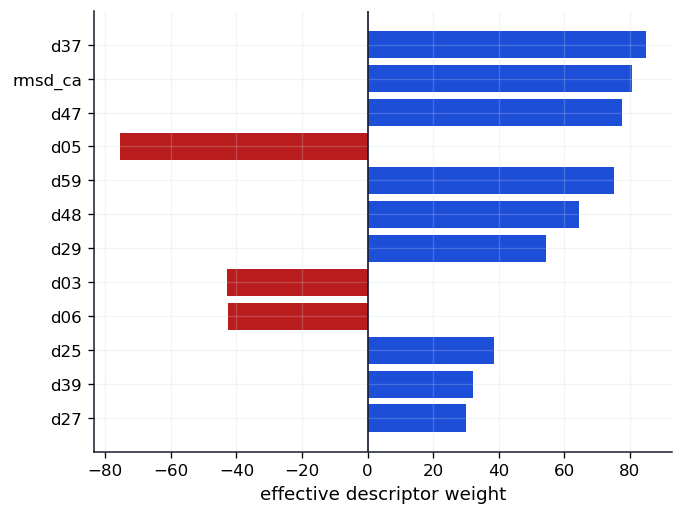

Tm: aggregated residue importance for the best linear combination


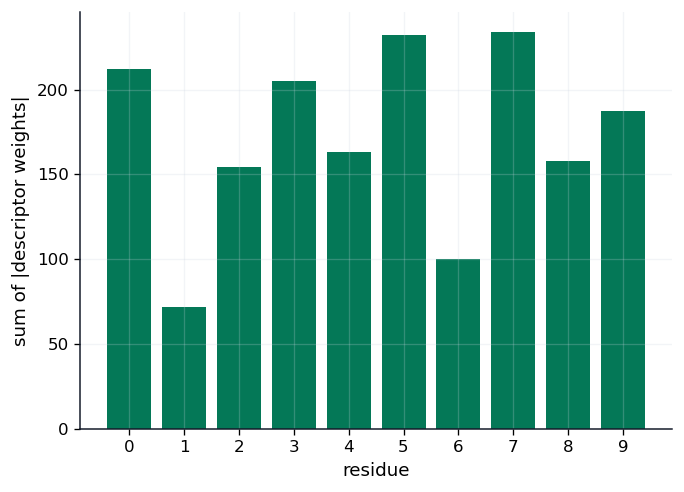

mfpt linear_combo: (2)


,feature_name,weight,abs_weight
0,rmsd_ca,-8.572601e+06,8.572601e+06
1,d38,-7.662747e+06,7.662747e+06
2,d08,7.576281e+06,7.576281e+06
3,d69,7.539777e+06,7.539777e+06
4,d07,-6.768415e+06,6.768415e+06
5,d27,-6.173876e+06,6.173876e+06
6,d58,5.975596e+06,5.975596e+06
7,d29,5.899995e+06,5.899995e+06
8,d17,-5.758899e+06,5.758899e+06
9,d09,-5.491253e+06,5.491253e+06


,residue,signed_weight_sum,abs_weight_sum
0,0,-7.015903e+06,2.224199e+07
1,1,-1.681323e+07,2.148247e+07
2,2,-7.133176e+06,1.893317e+07
3,3,-8.507017e+06,1.867292e+07
4,4,-7.313186e+06,1.384721e+07
5,5,9.361768e+06,1.521115e+07
6,6,4.041901e+06,2.061598e+07
7,7,-2.042214e+07,2.682892e+07
8,8,2.492458e+06,2.714601e+07
9,9,9.935222e+06,2.807281e+07


mfpt: top descriptor weights for the best linear combination


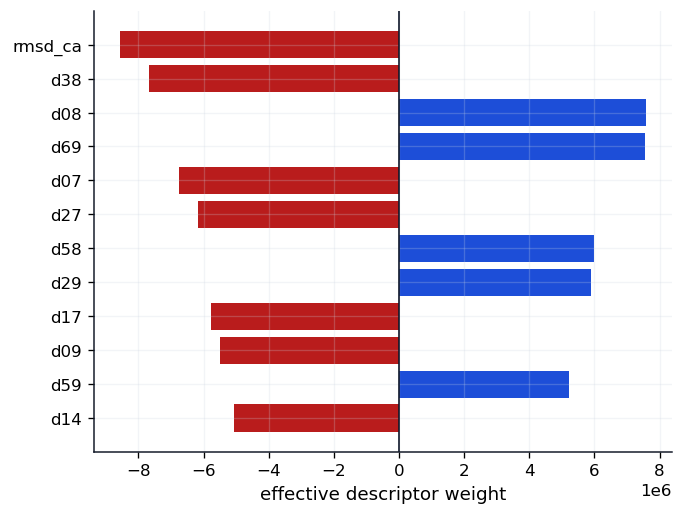

mfpt: aggregated residue importance for the best linear combination


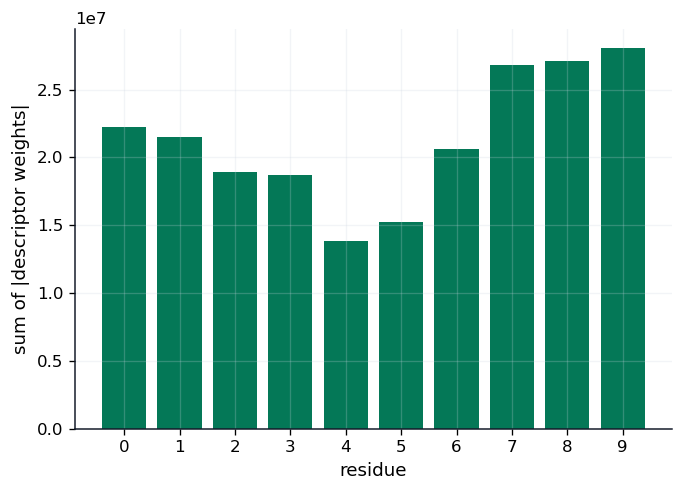

log_mfpt_ratio linear_combo: (1, 2, 3, 4)


,feature_name,weight,abs_weight
0,d59,-22.1940,22.1940
1,d05,18.5844,18.5844
2,rmsd_ca,-17.7406,17.7406
3,d47,-14.0596,14.0596
4,d15,-13.6779,13.6779
5,d36,-13.4255,13.4255
6,d25,-12.0987,12.0987
7,d37,-10.8978,10.8978
8,d08,-9.7678,9.7678
9,d03,9.7296,9.7296


,residue,signed_weight_sum,abs_weight_sum
0,0,21.6964,58.8400
1,1,-24.1623,27.8099
2,2,-15.9993,29.3288
3,3,-6.8500,41.7965
4,4,-15.1120,26.6747
5,5,-27.5006,68.4406
6,6,-33.4351,33.4351
7,7,-17.5293,32.3856
8,8,-0.5211,19.6592
9,9,-26.3191,60.8213


log_mfpt_ratio: top descriptor weights for the best linear combination


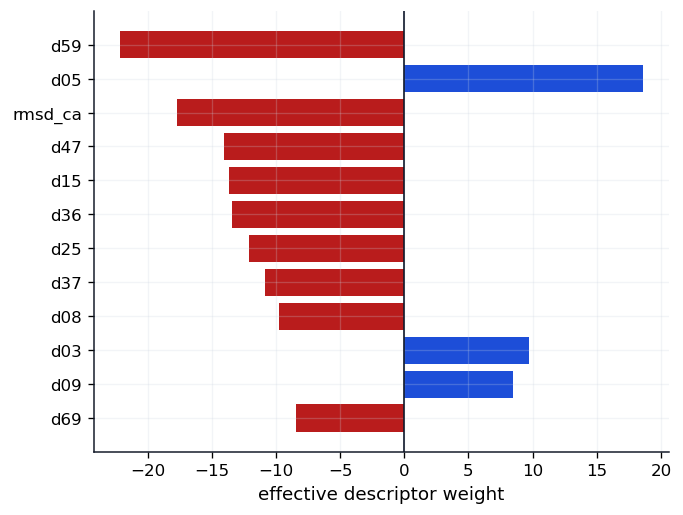

log_mfpt_ratio: aggregated residue importance for the best linear combination


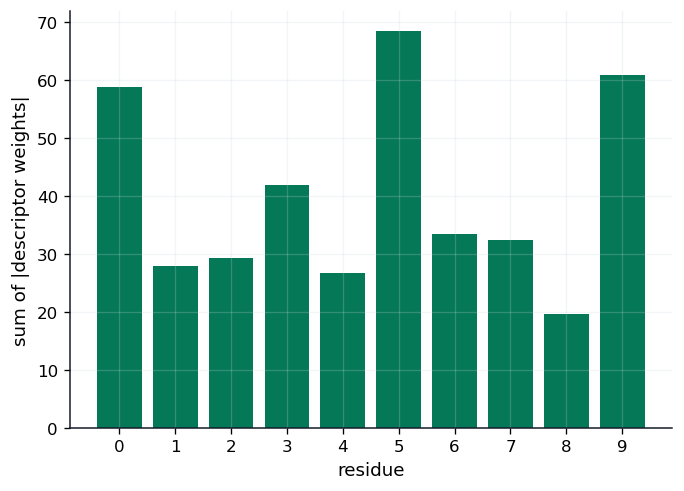

hlda_evalue linear_combo: (3)


,feature_name,weight,abs_weight
0,d37,2434.8875,2434.8875
1,d47,2208.1345,2208.1345
2,rmsd_ca,2094.0079,2094.0079
3,d48,2062.3816,2062.3816
4,d05,-2032.9830,2032.9830
5,d59,1943.0324,1943.0324
6,d29,1680.4873,1680.4873
7,d06,-1438.7780,1438.7780
8,d03,-1191.9906,1191.9906
9,d39,1132.9862,1132.9862


,residue,signed_weight_sum,abs_weight_sum
0,0,-5581.7039,6618.2633
1,1,-1511.8010,2146.5207
2,2,3975.6275,4893.3413
3,3,2350.3443,5973.7090
4,4,3440.5641,5307.5348
5,5,532.3999,5819.5331
6,6,-2229.5083,3417.8144
7,7,5173.8541,7116.8748
8,8,550.5308,5231.9278
9,9,3983.7873,5787.3160


hlda_evalue: top descriptor weights for the best linear combination


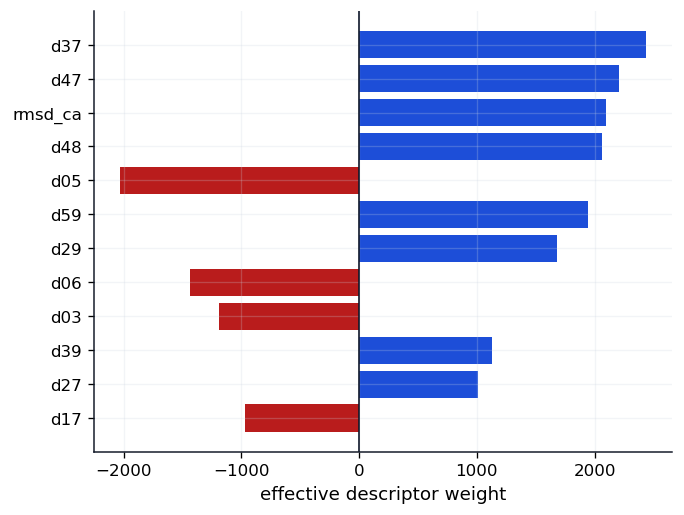

hlda_evalue: aggregated residue importance for the best linear combination


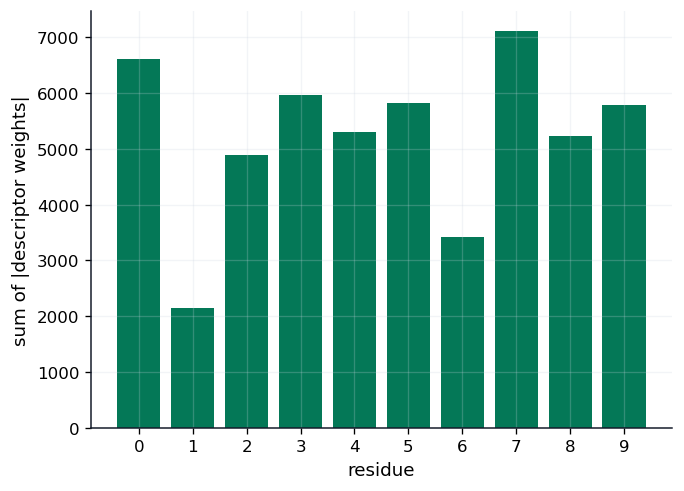

In [10]:
feature_names = list(packed['feature_names'])


def parse_descriptor_residues(name):
    if isinstance(name, str) and len(name) == 3 and name.startswith('d') and name[1:].isdigit():
        return [int(name[1]), int(name[2])]
    return []


def residue_weight_df(descriptor_df):
    rows = []
    for _, row in descriptor_df.iterrows():
        for residue_idx in row['residues']:
            rows.append({
                'residue': int(residue_idx),
                'signed_weight': float(row['weight']),
                'abs_weight': float(abs(row['weight'])),
            })
    if not rows:
        return pd.DataFrame(columns=['residue', 'signed_weight_sum', 'abs_weight_sum'])
    out = pd.DataFrame(rows).groupby('residue', as_index=False).agg(
        signed_weight_sum=('signed_weight', 'sum'),
        abs_weight_sum=('abs_weight', 'sum'),
    )
    return out.sort_values('residue', ascending=True).reset_index(drop=True)


def linear_combo_descriptor_weight_df(backbone, combo_item, feature_names):
    dv_weights = backbone.dv_head.weight.detach().cpu().numpy()  # [feat_dim, cv_count]
    combo_coef = np.asarray(combo_item['coef'][1:], dtype=float)
    combo_indices = np.asarray(combo_item['cv_indices'], dtype=int)
    if combo_indices.size == 0 or combo_coef.size == 0:
        return pd.DataFrame(columns=['feature_idx', 'feature_name', 'weight', 'abs_weight', 'residues'])
    effective_weights = dv_weights[:, combo_indices] @ combo_coef
    rows = []
    for feat_idx, (feature_name, weight) in enumerate(zip(feature_names, effective_weights)):
        residues = parse_descriptor_residues(feature_name)
        rows.append({
            'feature_idx': feat_idx,
            'feature_name': str(feature_name),
            'weight': float(weight),
            'abs_weight': float(abs(weight)),
            'residues': residues,
        })
    return pd.DataFrame(rows).sort_values('abs_weight', ascending=False).reset_index(drop=True)


def show_linear_combo_explainability(combo_item):
    metric_name = combo_item['metric_name']
    descriptor_df = linear_combo_descriptor_weight_df(explain_backbone, combo_item, feature_names)
    residue_df = residue_weight_df(descriptor_df)

    print(f"{metric_name} linear_combo: {compact_decoder_detail(combo_item['decoder_detail'])}")
    display(descriptor_df[['feature_name', 'weight', 'abs_weight']].head(12).round(4))
    display(residue_df.round(4))

    paper_caption(f'{metric_name}: top descriptor weights for the best linear combination')
    fig, ax = plt.subplots(1, 1, figsize=(5.8, 4.4))
    top_desc = descriptor_df.head(12).iloc[::-1]
    ax.barh(top_desc['feature_name'], top_desc['weight'], color=[PAPER_COLORS['red'] if w < 0 else PAPER_COLORS['blue'] for w in top_desc['weight']])
    ax.axvline(0.0, color='#0f172a', linewidth=1.0)
    style_axes(ax, xlabel='effective descriptor weight')
    plt.tight_layout()
    plt.show()

    paper_caption(f'{metric_name}: aggregated residue importance for the best linear combination')
    fig, ax = plt.subplots(1, 1, figsize=(5.8, 4.2))
    ax.bar(residue_df['residue'].astype(str), residue_df['abs_weight_sum'], color=PAPER_COLORS['green'])
    style_axes(ax, xlabel='residue', ylabel='sum of |descriptor weights|')
    plt.tight_layout()
    plt.show()

for combo_item in explain_combo_by_metric.values():
    show_linear_combo_explainability(combo_item)






### Best Single-CV Scatter for Explainability Targets


In [11]:
# Redundant combo-prediction scatter removed. Use the main decoder scatter section above.



### Linear-Combo CV Trajectories for Representative Folded/Unfolded Mutants

For each best `linear_combo` target, pick two whole test trajectories: one more folded-like and one more unfolded-like, then inspect the two most important CVs across the full trajectory.


Tm | linear_combo (3, 4)


,mutant,state,Tm,traj_id,n_frames,rmsd_ca_mean,cv_x,cv_y
0,P3C,folded,318.0,24,598,0.2146,cv_3,cv_4
1,P3C,unfolded,318.0,25,598,0.9532,cv_3,cv_4
2,Y9K,folded,386.0,68,598,0.2418,cv_3,cv_4
3,Y9K,unfolded,386.0,69,598,0.9720,cv_3,cv_4
4,D2R,folded,450.0,12,598,0.1445,cv_3,cv_4
5,D2R,unfolded,450.0,13,598,0.9199,cv_3,cv_4


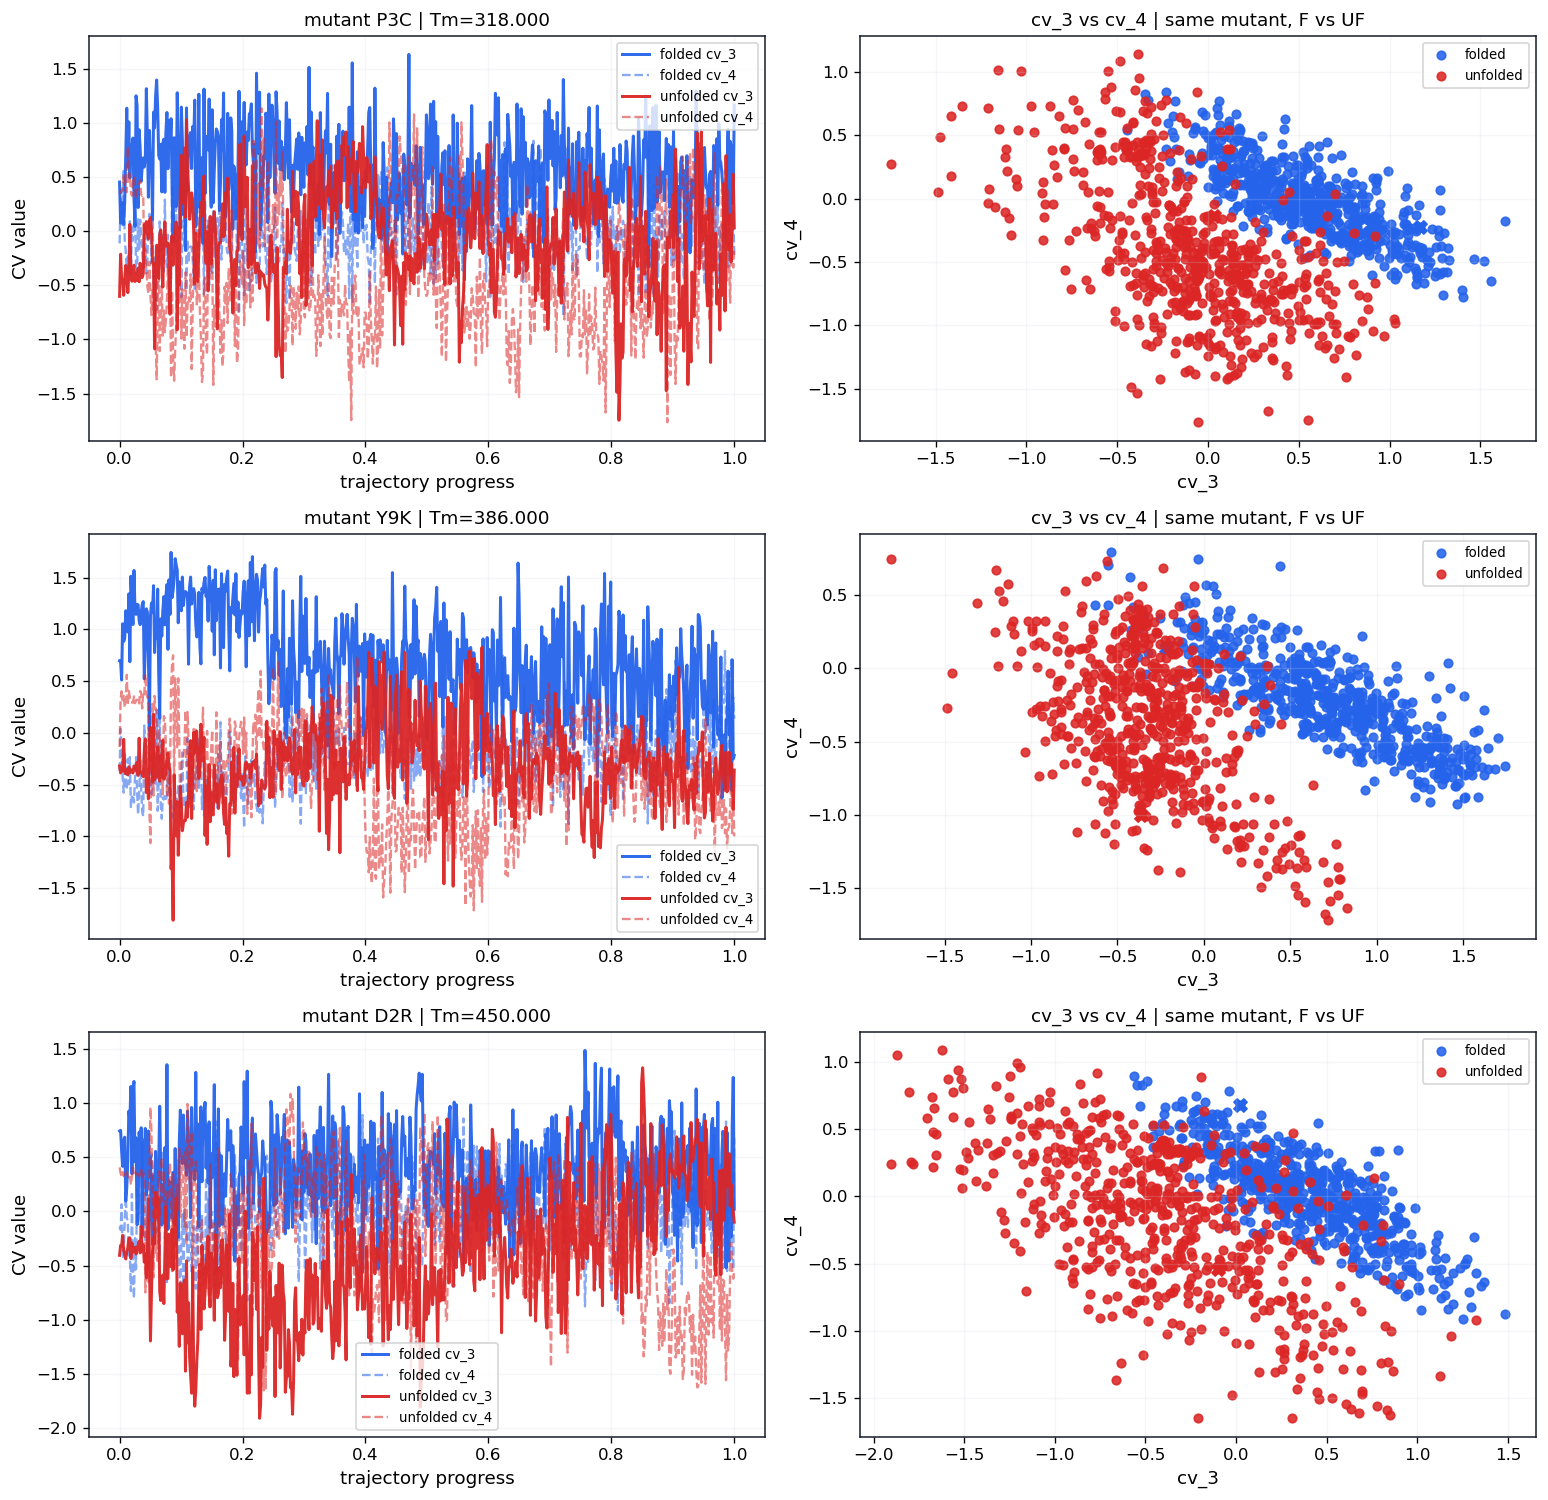

mfpt | linear_combo (2)


,mutant,state,mfpt,traj_id,n_frames,rmsd_ca_mean,cv_x,cv_y
0,Y9K,folded,1.658003e+04,68,598,0.2418,cv_2,cv_1
1,Y9K,unfolded,1.658003e+04,69,598,0.9720,cv_2,cv_1
2,D2Y,folded,6.734429e+05,14,598,0.1764,cv_2,cv_1
3,D2Y,unfolded,6.734429e+05,15,598,0.8244,cv_2,cv_1
4,T7V,folded,3.076061e+06,48,598,0.1330,cv_2,cv_1
5,T7V,unfolded,3.076061e+06,49,598,0.7732,cv_2,cv_1


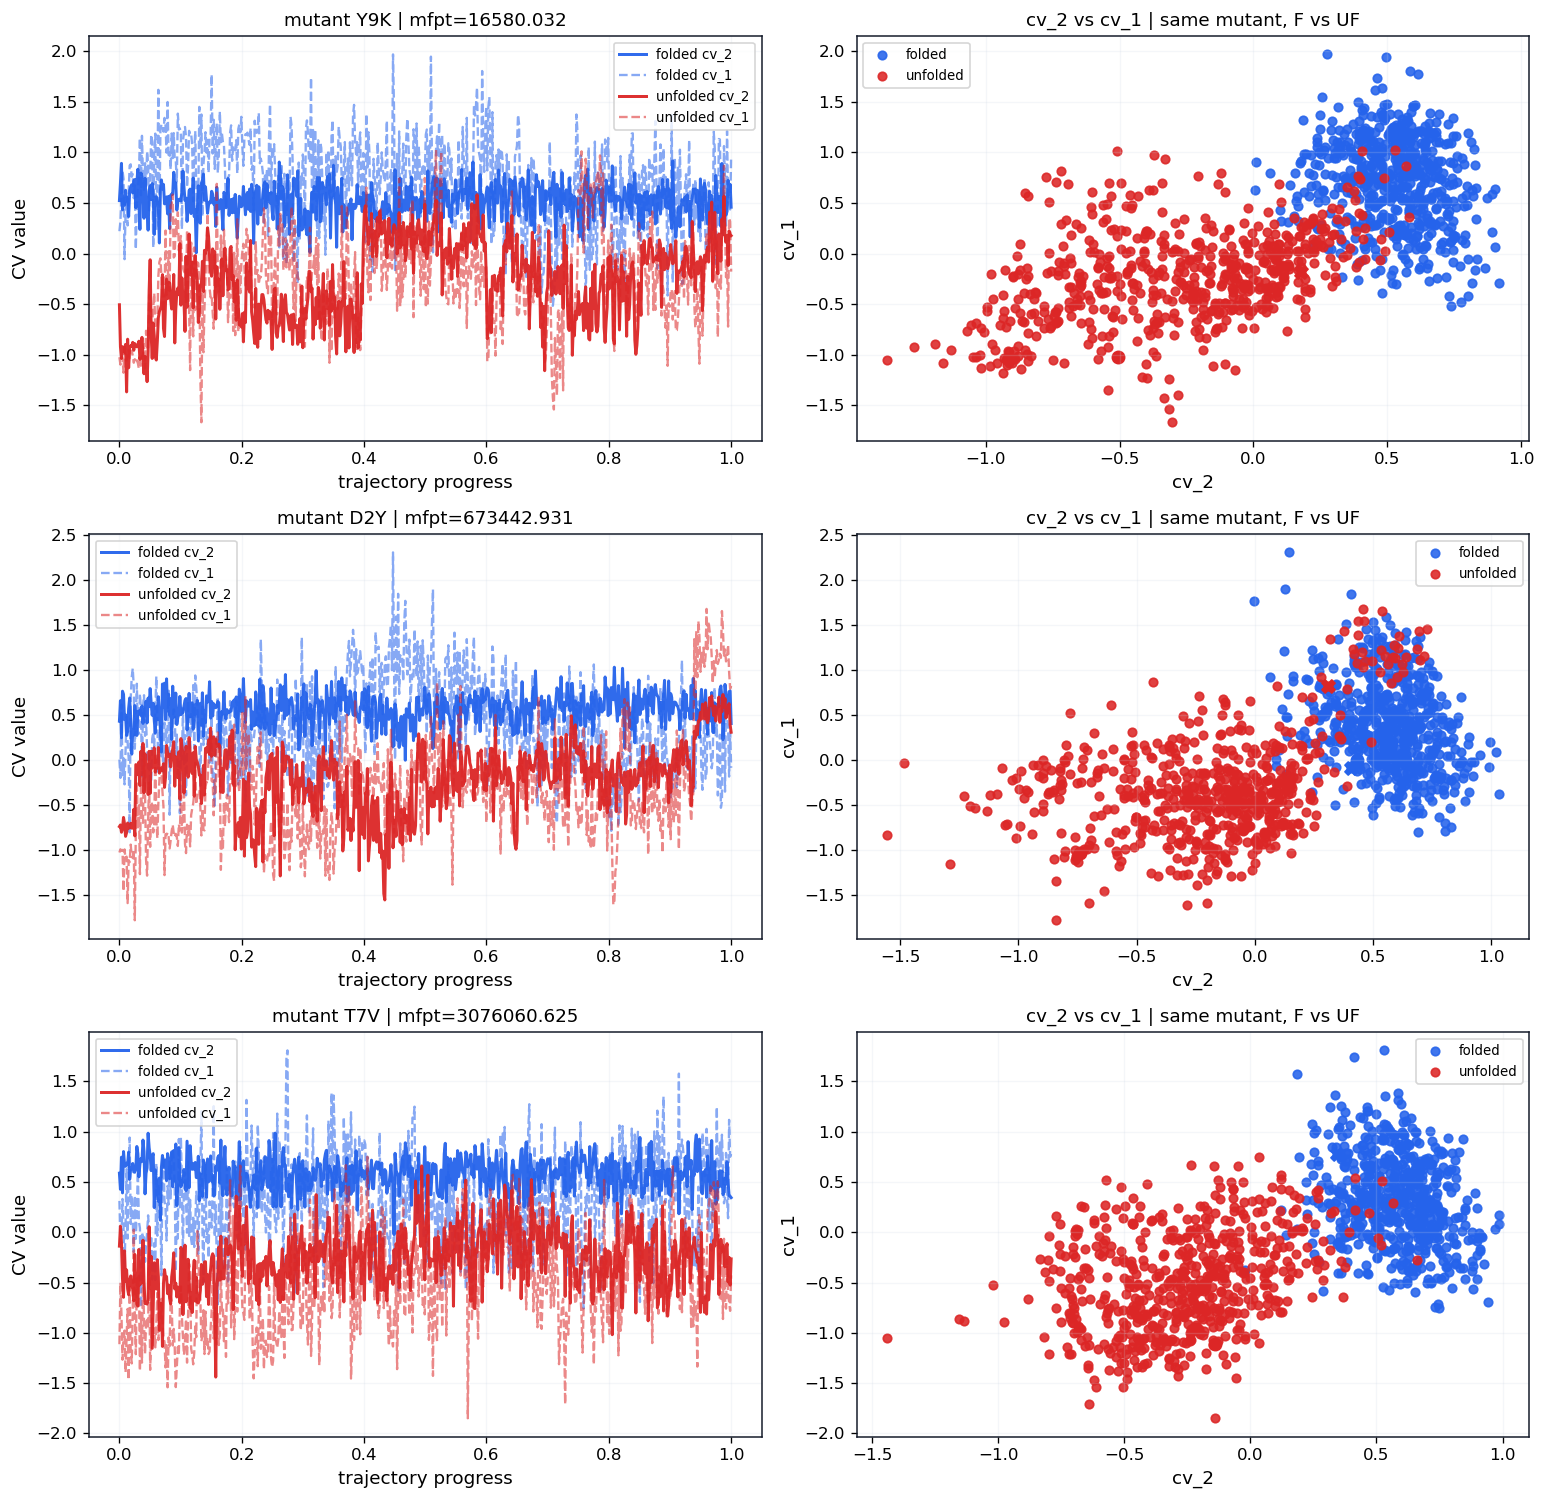

log_mfpt_ratio | linear_combo (1, 2, 3, 4)


,mutant,state,log_mfpt_ratio,traj_id,n_frames,rmsd_ca_mean,cv_x,cv_y
0,Y9K,folded,-3.6300,68,598,0.2418,cv_3,cv_4
1,Y9K,unfolded,-3.6300,69,598,0.9720,cv_3,cv_4
2,D2Y,folded,0.0742,14,598,0.1764,cv_3,cv_4
3,D2Y,unfolded,0.0742,15,598,0.8244,cv_3,cv_4
4,T7V,folded,1.5932,48,598,0.1330,cv_3,cv_4
5,T7V,unfolded,1.5932,49,598,0.7732,cv_3,cv_4


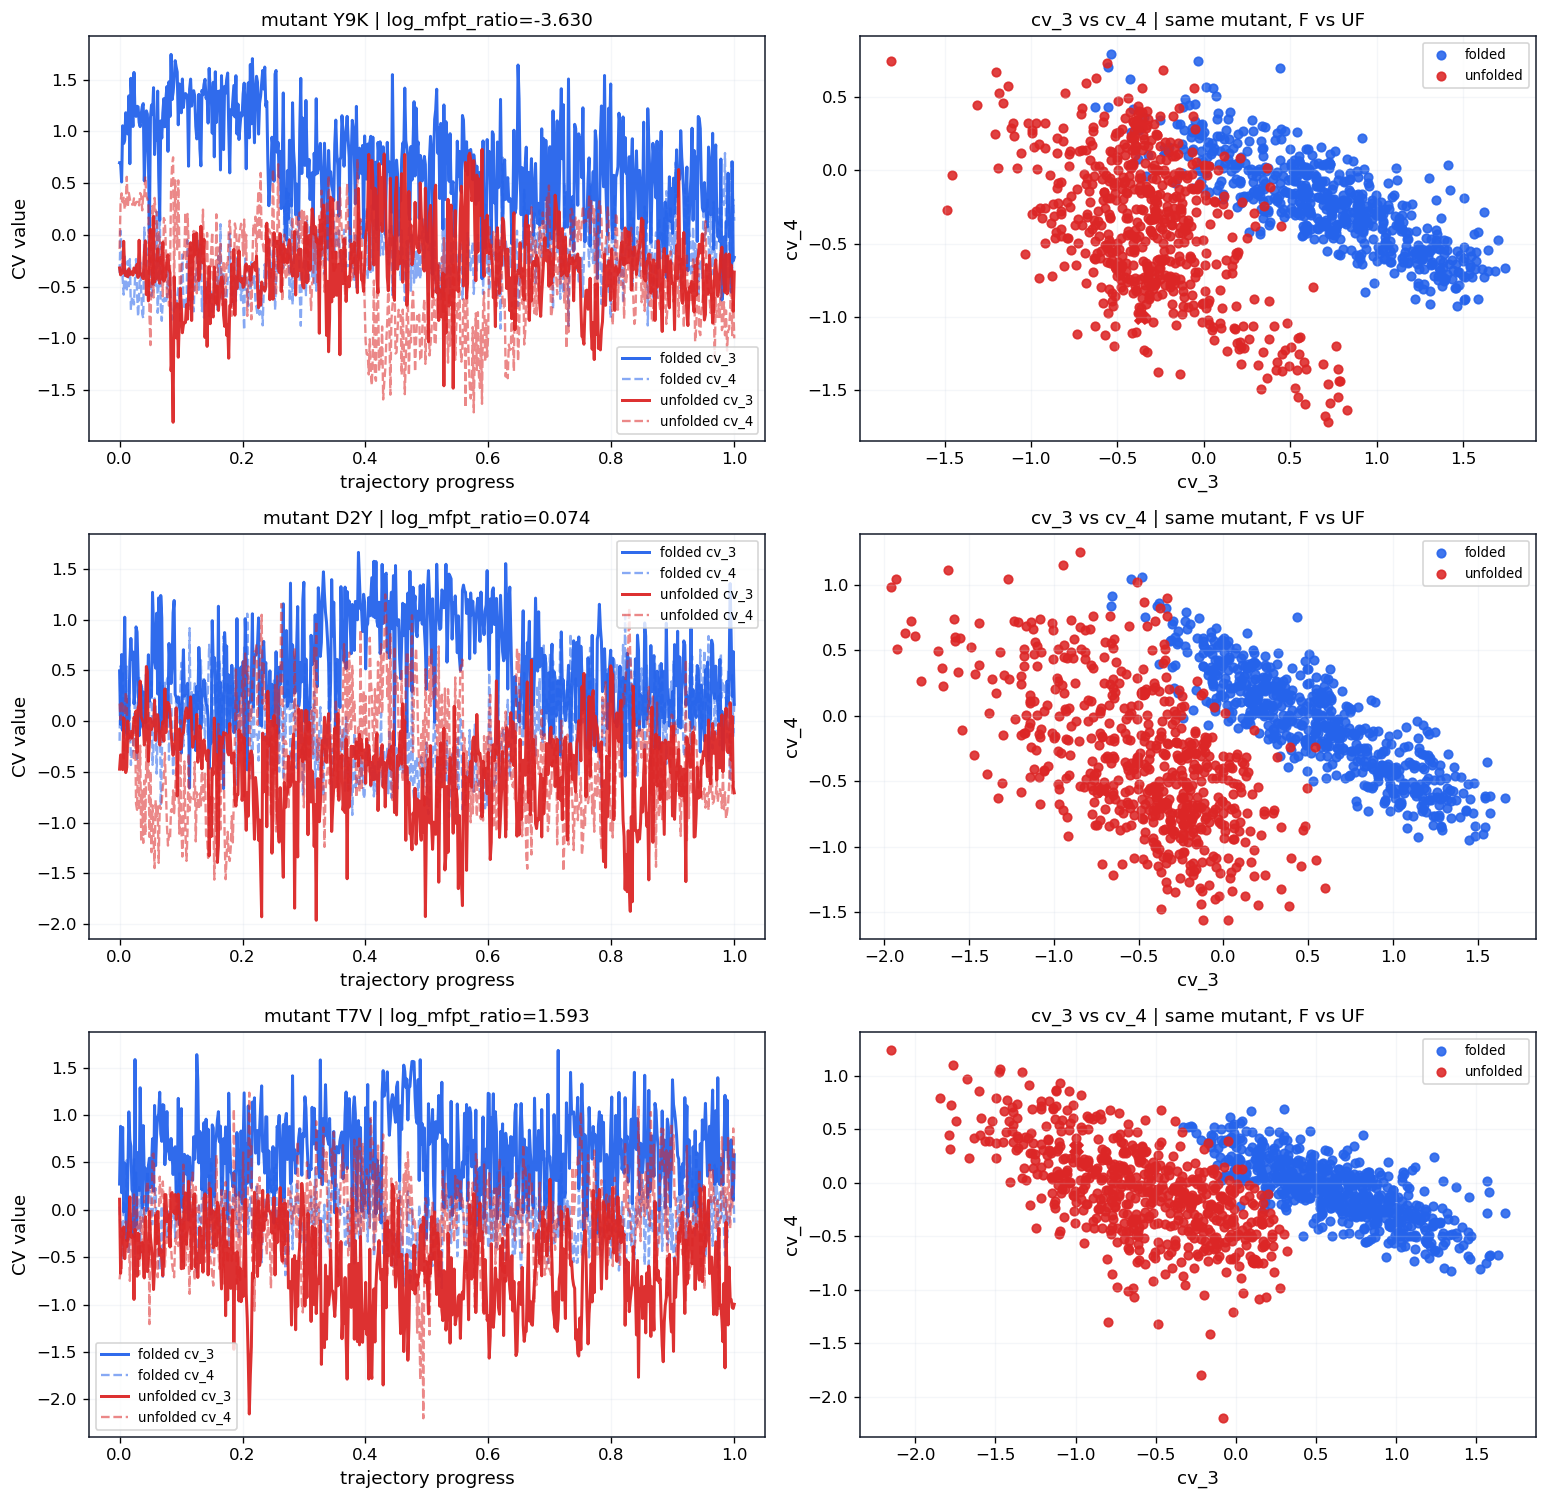

hlda_evalue | linear_combo (3)


,mutant,state,hlda_evalue,traj_id,n_frames,rmsd_ca_mean,cv_x,cv_y
0,Y9Q,folded,3864.4503,70,598,0.2088,cv_3,cv_1
1,Y9Q,unfolded,3864.4503,71,598,0.9364,cv_3,cv_1
2,E4Y,folded,5277.8082,22,598,0.1755,cv_3,cv_1
3,E4Y,unfolded,5277.8082,23,598,0.9507,cv_3,cv_1
4,P3M,folded,8467.2772,28,598,0.1419,cv_3,cv_1
5,P3M,unfolded,8467.2772,29,598,0.9212,cv_3,cv_1


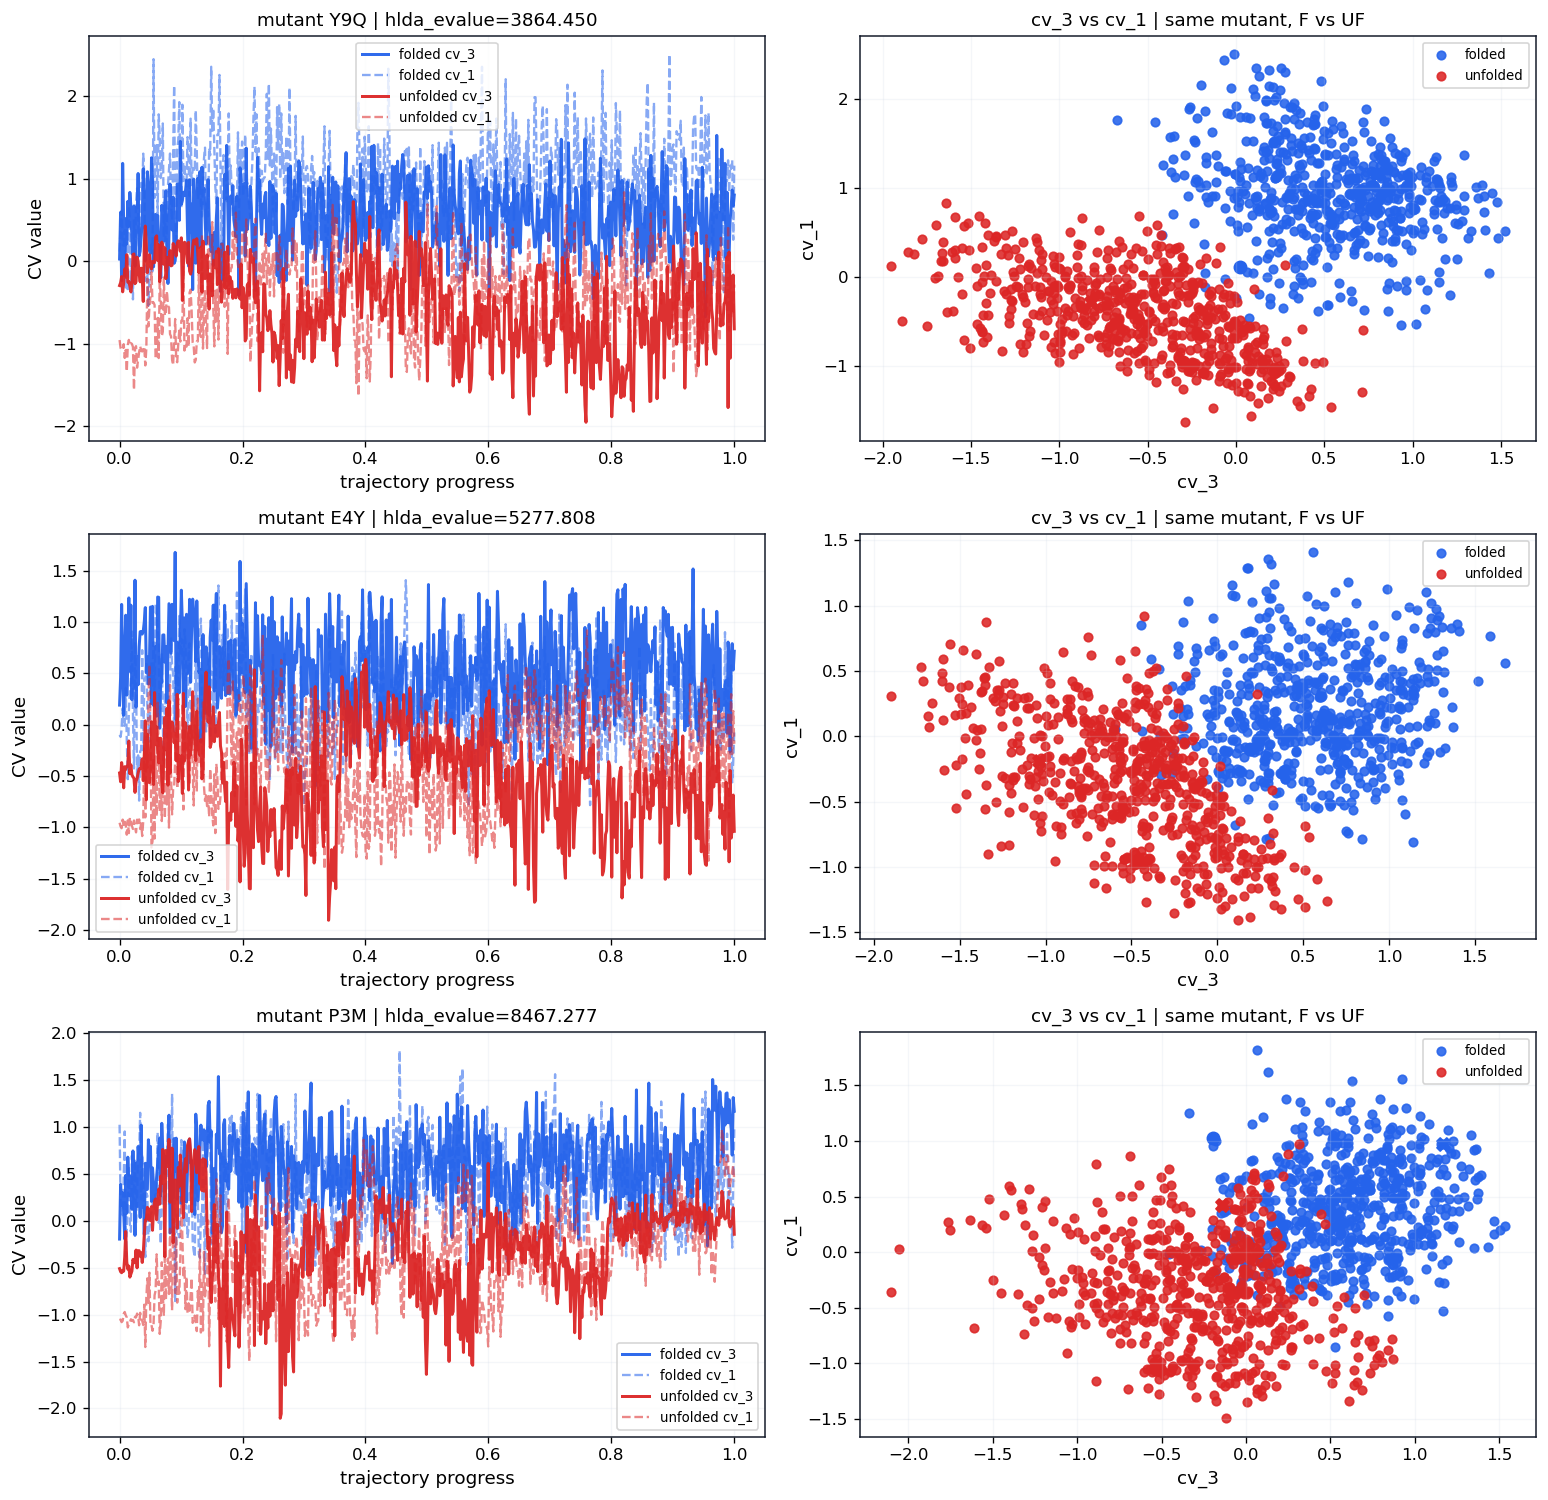

In [12]:
label_to_name = {int(k) if not isinstance(k, int) and str(k).isdigit() else k: v for k, v in packed['label_to_name'].items()}
feature_names_local = [str(name) for name in packed['feature_names']]
rmsd_feature_idx = feature_names_local.index('rmsd_ca') if 'rmsd_ca' in feature_names_local else None


def top_two_combo_cvs(combo_item):
    feature_cols = list(combo_item.get('feature_cols', []))
    coef_full = np.asarray(combo_item.get('coef', []), dtype=float)
    coef = coef_full[1:] if coef_full.size > 1 else np.asarray([], dtype=float)
    if len(feature_cols) == 0:
        detail = str(combo_item.get('decoder_detail', ''))
        if 'cv_' in detail:
            feature_cols = [tok.strip() for tok in detail.split('+') if tok.strip().startswith('cv_')]
    if len(feature_cols) == 0:
        feature_cols = sorted([col for col in combo_item['train_df'].columns if col.startswith('cv_')], key=lambda x: int(x.split('_')[1]))
    if coef.size == len(feature_cols) and len(feature_cols) > 0:
        order = np.argsort(-np.abs(coef))
        selected = [feature_cols[i] for i in order[:min(2, len(feature_cols))]]
    else:
        selected = feature_cols[:min(2, len(feature_cols))]
    if len(selected) == 1:
        fallback = [c for c in sorted([col for col in combo_item['train_df'].columns if col.startswith('cv_')], key=lambda x: int(x.split('_')[1])) if c not in selected]
        if fallback:
            selected.append(fallback[0])
    return selected


def extract_cv_rows_for_split(x_tensor, sample_df):
    rows = []
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x_tensor), batch_size=batch_size, shuffle=False, drop_last=False)
    with torch.no_grad():
        for (xh,) in loader:
            rows.append(explain_backbone.encode_cv(xh.to(device)).detach().cpu())
    cv_all = torch.cat(rows, dim=0).numpy()
    out = sample_df.reset_index(drop=True).copy()
    for cv_i in range(cv_all.shape[1]):
        out[f'cv_{cv_i + 1}'] = cv_all[:, cv_i]
    out['state'] = out['traj_id'].map(lambda tid: str(label_to_name[int(labels[int(tid)].item())]))
    out['traj_progress'] = out.groupby('traj_id').cumcount()
    out['traj_progress'] = out['traj_progress'] / out.groupby('traj_id')['traj_progress'].transform('max').replace(0, 1)
    rmsd_vals = []
    for _, row in out.iterrows():
        frame_idx = int(offsets[int(row['traj_id'])].item()) + int(row['t'])
        rmsd_vals.append(float(x_all[frame_idx, rmsd_feature_idx].item()))
    out['rmsd_ca'] = rmsd_vals
    return out


def representative_mutants_from_combo(combo_item, n_examples=3):
    test_df = combo_item['test_df'][['mutant', combo_item['metric_name']]].copy().sort_values(combo_item['metric_name']).reset_index(drop=True)
    if len(test_df) == 0:
        return []
    candidate_idx = np.unique(np.linspace(0, len(test_df) - 1, num=min(n_examples, len(test_df))).round().astype(int))
    return test_df.iloc[candidate_idx]['mutant'].astype(str).tolist()


def show_combo_trajectory_behavior(combo_item, split_name='test', n_examples=3):
    metric_name = combo_item['metric_name']
    cv_cols = top_two_combo_cvs(combo_item)
    if len(cv_cols) < 2:
        print(f'Not enough CV columns available for {metric_name}: {cv_cols}')
        return

    if split_name == 'test':
        x_tensor = explain_split_payload['test_x']
        sample_df = explain_split_payload['test_samples_df']
        metric_df = combo_item['test_df']
    elif split_name == 'val':
        x_tensor = explain_split_payload['val_x']
        sample_df = explain_split_payload['val_samples_df']
        metric_df = combo_item['val_df']
    else:
        x_tensor = explain_split_payload['train_x']
        sample_df = explain_split_payload['train_samples_df']
        metric_df = combo_item['train_df']

    frame_df_all = extract_cv_rows_for_split(x_tensor, sample_df)
    chosen_mutants = representative_mutants_from_combo(combo_item, n_examples=n_examples)
    frame_df = frame_df_all[frame_df_all['mutant'].astype(str).isin(chosen_mutants)].copy()
    if frame_df.empty:
        print(f'No frame-level data available for {metric_name}.')
        return

    print(f"{metric_name} | linear_combo {compact_decoder_detail(combo_item['decoder_detail'])}")
    summary_rows = []
    for mutant_name in chosen_mutants:
        for state_name in ['folded', 'unfolded']:
            sub = frame_df[(frame_df['mutant'].astype(str) == str(mutant_name)) & (frame_df['state'] == state_name)].copy().sort_values('t')
            if sub.empty:
                continue
            target_value = float(metric_df.loc[metric_df['mutant'].astype(str) == str(mutant_name), metric_name].iloc[0])
            summary_rows.append({
                'mutant': mutant_name,
                'state': state_name,
                metric_name: target_value,
                'traj_id': int(sub['traj_id'].iloc[0]),
                'n_frames': int(len(sub)),
                'rmsd_ca_mean': float(sub['rmsd_ca'].mean()),
                'cv_x': cv_cols[0],
                'cv_y': cv_cols[1],
            })
    display(pd.DataFrame(summary_rows).round(4))

    fig, axes = plt.subplots(len(chosen_mutants), 2, figsize=(13.0, 4.2 * len(chosen_mutants)), squeeze=False)
    state_palette = {'folded': '#2563eb', 'unfolded': '#dc2626'}
    for row_i, mutant_name in enumerate(chosen_mutants):
        ax = axes[row_i, 0]
        ax2 = axes[row_i, 1]
        target_value = float(metric_df.loc[metric_df['mutant'].astype(str) == str(mutant_name), metric_name].iloc[0])
        for state_name in ['folded', 'unfolded']:
            sub = frame_df[(frame_df['mutant'].astype(str) == str(mutant_name)) & (frame_df['state'] == state_name)].copy().sort_values('t')
            if sub.empty:
                continue
            ax.plot(sub['traj_progress'], sub[cv_cols[0]], linewidth=1.8, color=state_palette[state_name], alpha=0.95, label=f'{state_name} {cv_cols[0]}')
            ax.plot(sub['traj_progress'], sub[cv_cols[1]], linewidth=1.4, color=state_palette[state_name], alpha=0.55, linestyle='--', label=f'{state_name} {cv_cols[1]}')
            ax2.scatter(sub[cv_cols[0]], sub[cv_cols[1]], s=26, alpha=0.88, color=state_palette[state_name], label=state_name)
            x = sub[cv_cols[0]].to_numpy(dtype=float)
            y = sub[cv_cols[1]].to_numpy(dtype=float)
            ax2.scatter(x[0], y[0], color=state_palette[state_name], s=54, marker='o')
            ax2.scatter(x[-1], y[-1], color=state_palette[state_name], s=62, marker='X')
        ax.set_title(f'mutant {mutant_name} | {metric_name}={target_value:.3f}')
        ax.set_xlabel('trajectory progress')
        ax.set_ylabel('CV value')
        ax.grid(alpha=0.2)
        ax.legend(loc='best', fontsize=8)
        ax2.set_xlabel(cv_cols[0])
        ax2.set_ylabel(cv_cols[1])
        ax2.set_title(f'{cv_cols[0]} vs {cv_cols[1]} | same mutant, F vs UF')
        ax2.grid(alpha=0.2)
        ax2.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

for combo_item in explain_combo_by_metric.values():
    show_combo_trajectory_behavior(combo_item, split_name='test', n_examples=3)






### Do The Selected CVs Behave Like Distance Descriptors?

For the top CVs used by the best `linear_combo`, inspect:
- which descriptors they load onto most strongly through `dv_head`
- whether those same descriptors are strongly reconstructable from the CVs frame-by-frame
- whether the relation looks similar in folded and unfolded trajectories



Tm | combo (3, 4)
Using real folded/unfolded trajectory labels from the packed file.


,cv,feature,loading,abs_loading,pearson,spearman,fit_r2,std_cv,std_descriptor,std_ratio_desc_over_cv
0,cv_3,d37,-0.4472,0.4472,-0.6456,-0.5632,0.4168,0.6210,0.3416,0.5500
1,cv_3,d47,-0.4056,0.4056,-0.6519,-0.6067,0.4250,0.6210,0.1424,0.2294
2,cv_3,rmsd_ca,-0.3846,0.3846,-0.6525,-0.5837,0.4258,0.6210,0.3780,0.6088
3,cv_4,d15,-0.4486,0.4486,-0.2797,-0.2467,0.0782,0.4674,0.2450,0.5241
4,cv_4,d04,-0.4145,0.4145,-0.2650,-0.2480,0.0702,0.4674,0.0956,0.2046
5,cv_4,d69,-0.3749,0.3749,-0.1610,-0.1530,0.0259,0.4674,0.0594,0.1271


cv_3: top descriptor loadings


,feature,weight,abs_weight
0,d37,-0.4472,0.4472
1,d47,-0.4056,0.4056
2,rmsd_ca,-0.3846,0.3846
3,d48,-0.3788,0.3788
4,d05,0.3734,0.3734
5,d59,-0.3569,0.3569
6,d29,-0.3087,0.3087
7,d06,0.2643,0.2643


cv_4: top descriptor loadings


,feature,weight,abs_weight
0,d15,-0.4486,0.4486
1,d04,-0.4145,0.4145
2,d69,-0.3749,0.3749
3,d06,-0.3561,0.3561
4,d08,-0.3510,0.3510
5,d39,0.3500,0.3500
6,rmsd_ca,-0.3458,0.3458
7,d48,0.3440,0.3440


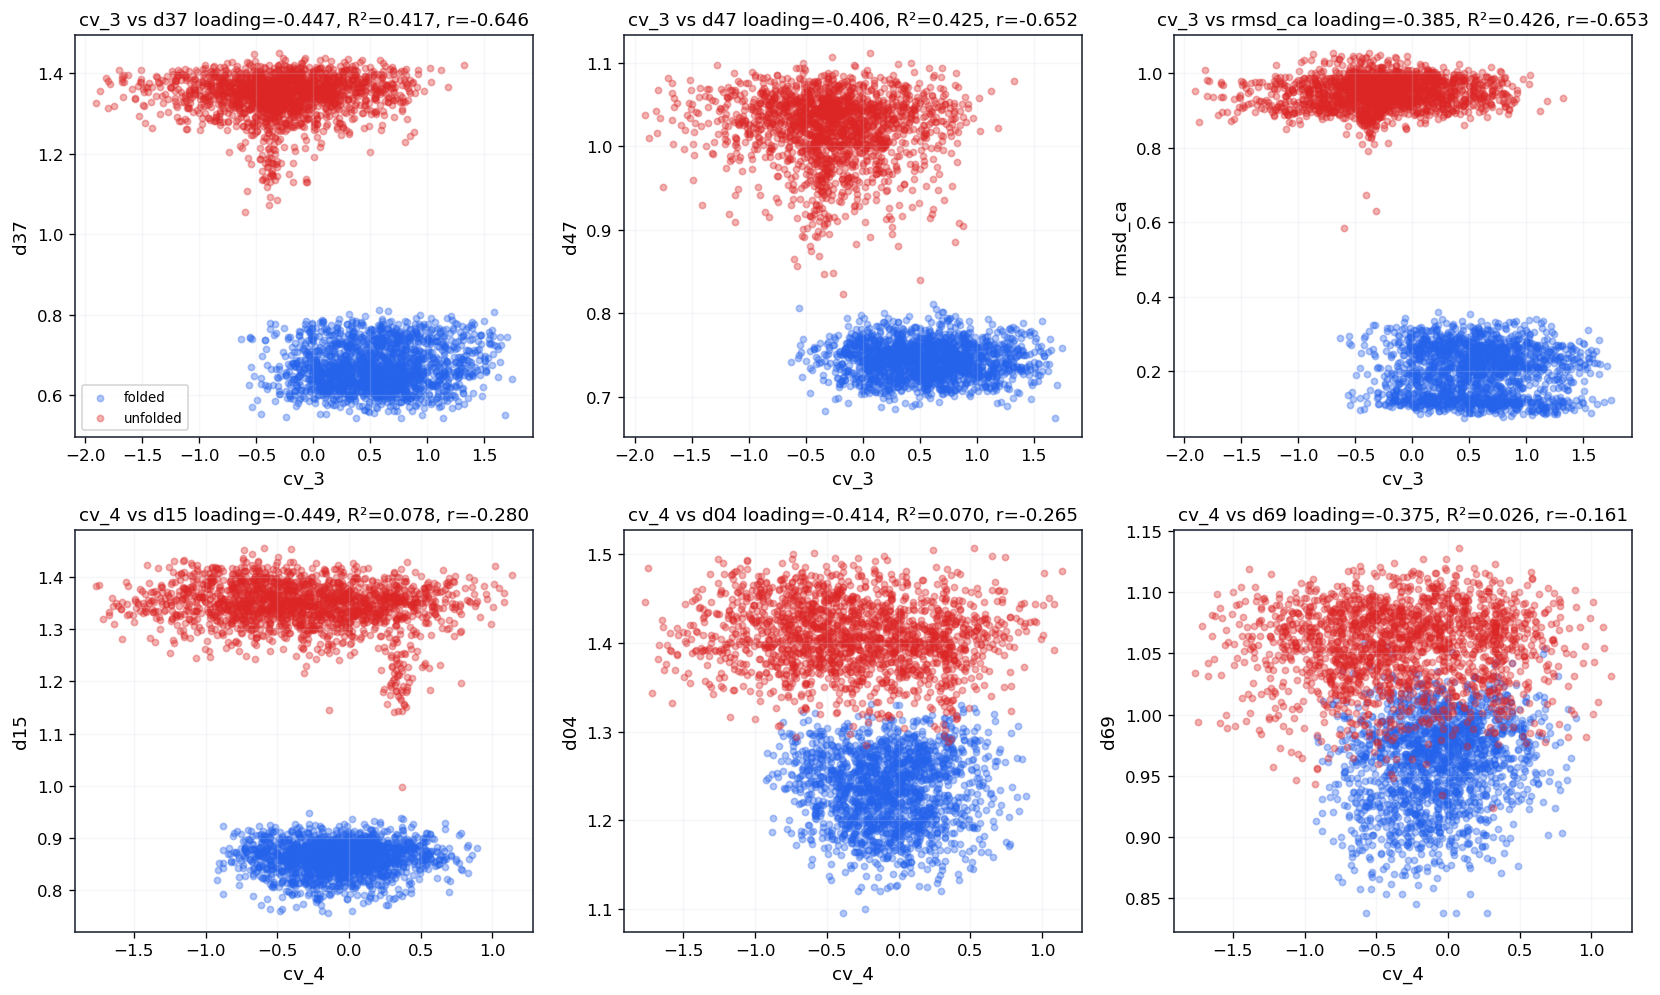

mfpt | combo (2)
Using real folded/unfolded trajectory labels from the packed file.


,cv,feature,loading,abs_loading,pearson,spearman,fit_r2,std_cv,std_descriptor,std_ratio_desc_over_cv
0,cv_2,rmsd_ca,0.3769,0.3769,-0.7871,-0.7359,0.6195,0.4882,0.3512,0.7193
1,cv_2,d38,0.3369,0.3369,-0.7620,-0.7297,0.5806,0.4882,0.3262,0.6681
2,cv_2,d08,-0.3331,0.3331,-0.8111,-0.7351,0.6578,0.4882,0.9872,2.0221
3,cv_1,d59,0.4552,0.4552,-0.5182,-0.5503,0.2686,0.6515,0.1217,0.1869
4,cv_1,d29,0.4207,0.4207,-0.5974,-0.5628,0.3569,0.6515,0.7174,1.1012
5,cv_1,d47,0.4133,0.4133,-0.4982,-0.5242,0.2482,0.6515,0.1280,0.1964


cv_2: top descriptor loadings


,feature,weight,abs_weight
0,rmsd_ca,0.3769,0.3769
1,d38,0.3369,0.3369
2,d08,-0.3331,0.3331
3,d69,-0.3315,0.3315
4,d07,0.2976,0.2976
5,d27,0.2714,0.2714
6,d58,-0.2627,0.2627
7,d29,-0.2594,0.2594


cv_1: top descriptor loadings


,feature,weight,abs_weight
0,d59,0.4552,0.4552
1,d29,0.4207,0.4207
2,d47,0.4133,0.4133
3,d69,0.4049,0.4049
4,d39,0.3880,0.3880
5,d15,0.3596,0.3596
6,d27,-0.3472,0.3472
7,d18,-0.3323,0.3323


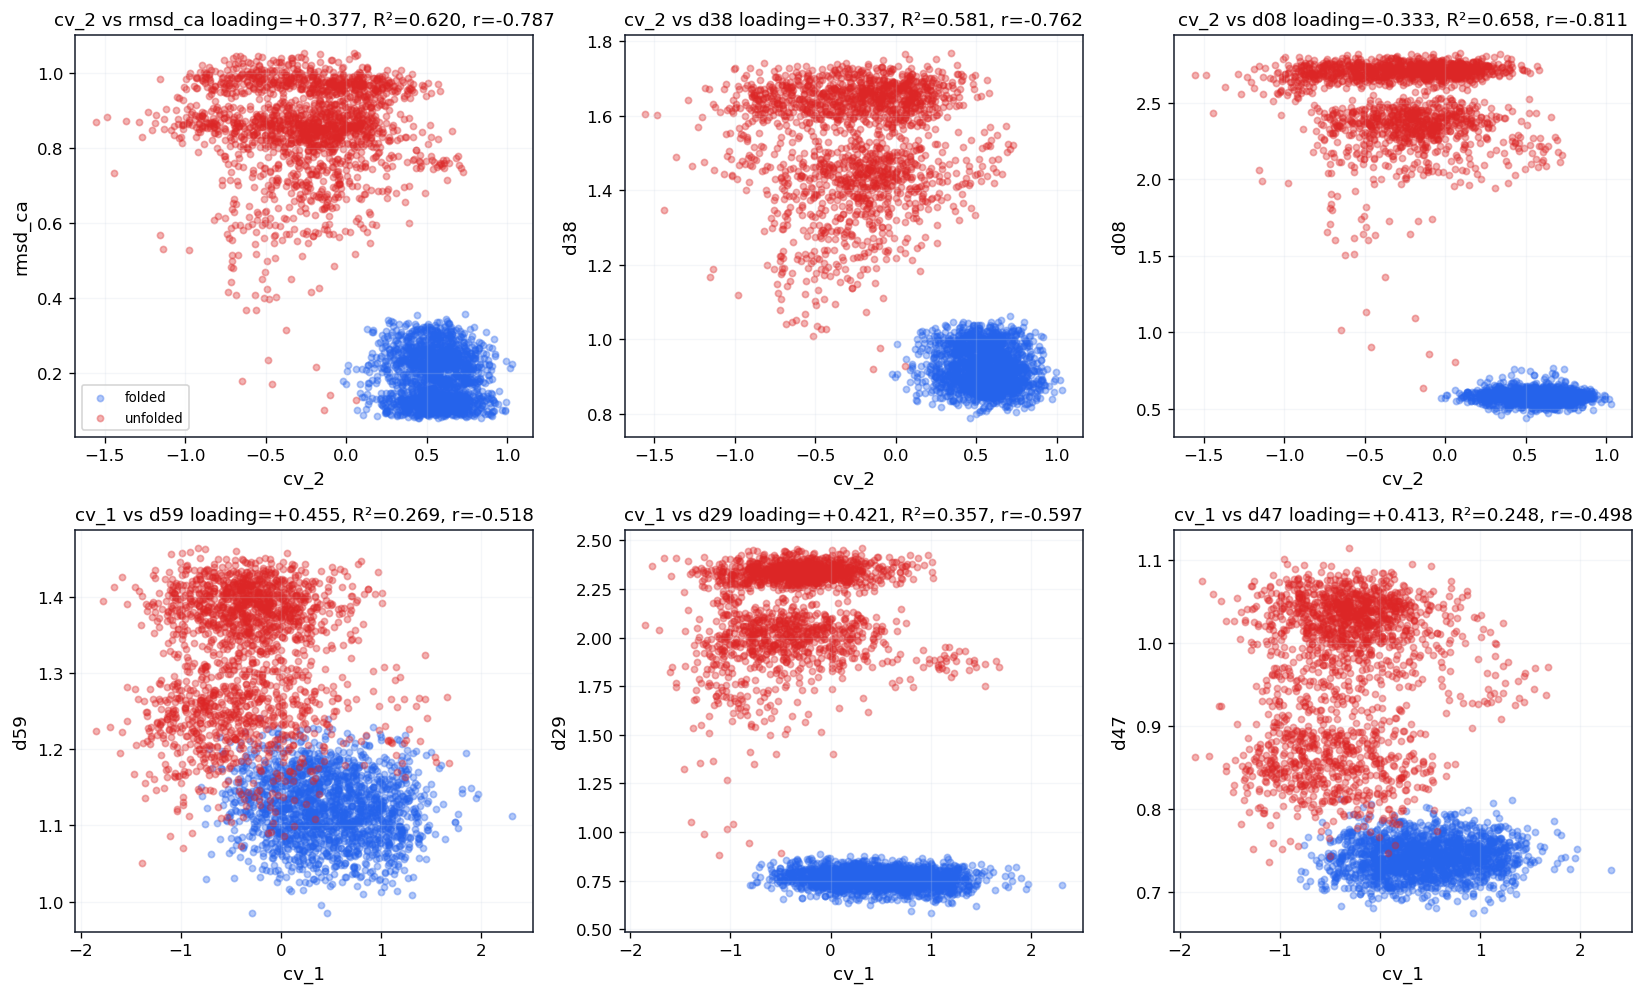

log_mfpt_ratio | combo (1, 2, 3, 4)
Using real folded/unfolded trajectory labels from the packed file.


,cv,feature,loading,abs_loading,pearson,spearman,fit_r2,std_cv,std_descriptor,std_ratio_desc_over_cv
0,cv_3,d37,-0.4472,0.4472,-0.6889,-0.6508,0.4746,0.7097,0.2948,0.4154
1,cv_3,d47,-0.4056,0.4056,-0.6183,-0.6604,0.3823,0.7097,0.1280,0.1803
2,cv_3,rmsd_ca,-0.3846,0.3846,-0.7334,-0.6850,0.5379,0.7097,0.3512,0.4948
3,cv_4,d15,-0.4486,0.4486,-0.1813,-0.1552,0.0329,0.4419,0.1953,0.4421
4,cv_4,d04,-0.4145,0.4145,-0.2084,-0.1800,0.0434,0.4419,0.0639,0.1446
5,cv_4,d69,-0.3749,0.3749,-0.1100,-0.1035,0.0121,0.4419,0.0557,0.1260


cv_3: top descriptor loadings


,feature,weight,abs_weight
0,d37,-0.4472,0.4472
1,d47,-0.4056,0.4056
2,rmsd_ca,-0.3846,0.3846
3,d48,-0.3788,0.3788
4,d05,0.3734,0.3734
5,d59,-0.3569,0.3569
6,d29,-0.3087,0.3087
7,d06,0.2643,0.2643


cv_4: top descriptor loadings


,feature,weight,abs_weight
0,d15,-0.4486,0.4486
1,d04,-0.4145,0.4145
2,d69,-0.3749,0.3749
3,d06,-0.3561,0.3561
4,d08,-0.3510,0.3510
5,d39,0.3500,0.3500
6,rmsd_ca,-0.3458,0.3458
7,d48,0.3440,0.3440


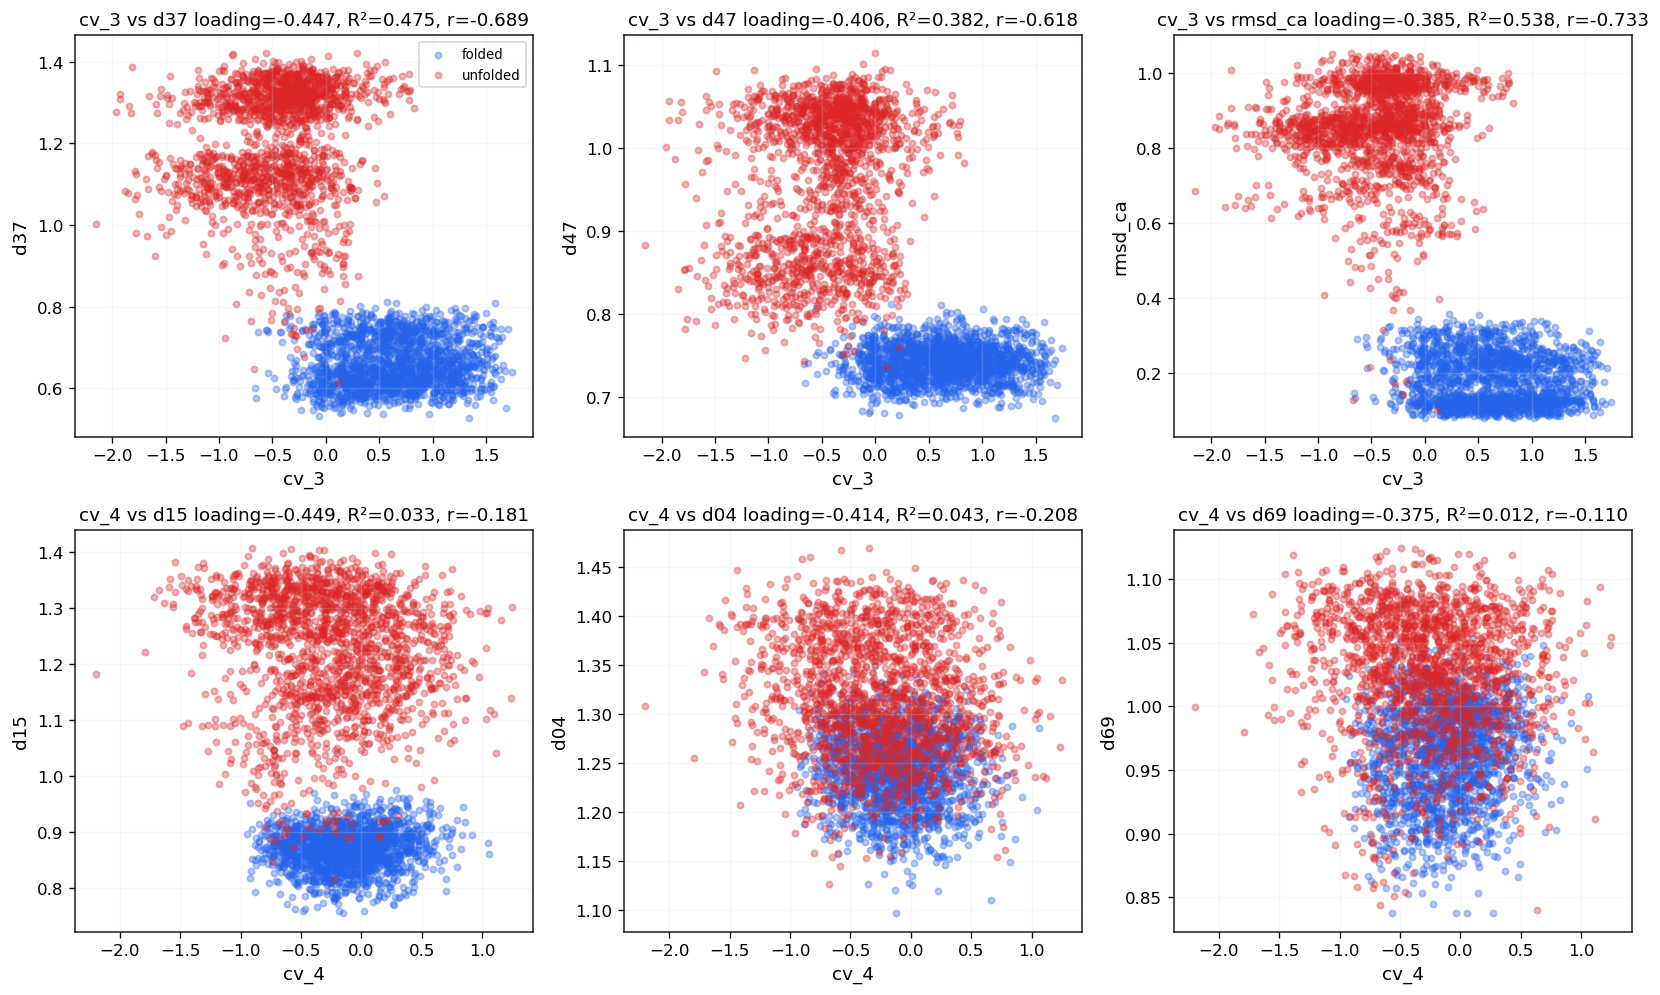

hlda_evalue | combo (3)
Using real folded/unfolded trajectory labels from the packed file.


,cv,feature,loading,abs_loading,pearson,spearman,fit_r2,std_cv,std_descriptor,std_ratio_desc_over_cv
0,cv_3,d37,-0.4472,0.4472,-0.7386,-0.6796,0.5455,0.6831,0.3337,0.4885
1,cv_3,d47,-0.4056,0.4056,-0.7202,-0.6729,0.5187,0.6831,0.1307,0.1913
2,cv_3,rmsd_ca,-0.3846,0.3846,-0.7502,-0.7149,0.5627,0.6831,0.3832,0.5609
3,cv_1,d59,0.4552,0.4552,-0.6210,-0.6022,0.3856,0.6861,0.1240,0.1807
4,cv_1,d29,0.4207,0.4207,-0.6462,-0.5819,0.4176,0.6861,0.7763,1.1314
5,cv_1,d47,0.4133,0.4133,-0.6249,-0.5806,0.3905,0.6861,0.1307,0.1905


cv_3: top descriptor loadings


,feature,weight,abs_weight
0,d37,-0.4472,0.4472
1,d47,-0.4056,0.4056
2,rmsd_ca,-0.3846,0.3846
3,d48,-0.3788,0.3788
4,d05,0.3734,0.3734
5,d59,-0.3569,0.3569
6,d29,-0.3087,0.3087
7,d06,0.2643,0.2643


cv_1: top descriptor loadings


,feature,weight,abs_weight
0,d59,0.4552,0.4552
1,d29,0.4207,0.4207
2,d47,0.4133,0.4133
3,d69,0.4049,0.4049
4,d39,0.3880,0.3880
5,d15,0.3596,0.3596
6,d27,-0.3472,0.3472
7,d18,-0.3323,0.3323


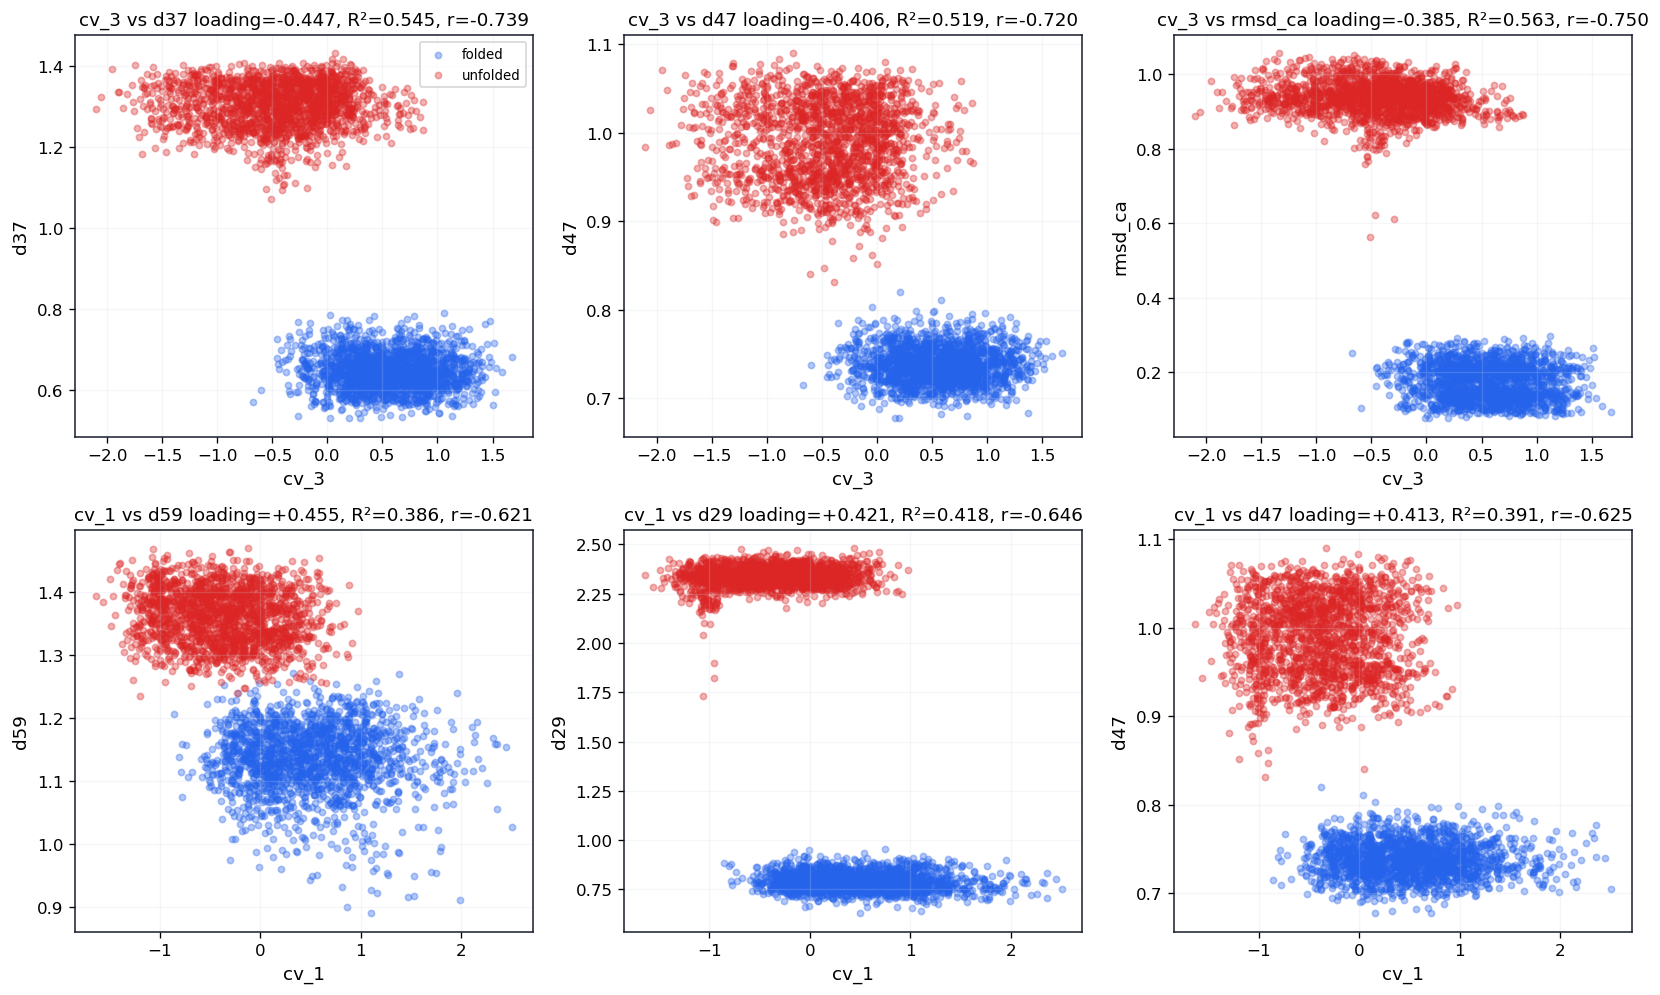

In [13]:
def per_frame_feature_df_for_mutants(sample_df, x_tensor, mutant_names):
    frame_df = extract_cv_rows_for_split(x_tensor, sample_df)
    frame_df = frame_df[frame_df['mutant'].astype(str).isin([str(m) for m in mutant_names])].copy()
    if frame_df.empty:
        return frame_df
    feature_rows = []
    for _, row in frame_df.iterrows():
        frame_idx = int(offsets[int(row['traj_id'])].item()) + int(row['t'])
        feature_rows.append(x_all[frame_idx].detach().cpu().numpy())
    feat_arr = np.asarray(feature_rows, dtype=float)
    for feat_i, feat_name in enumerate(feature_names):
        frame_df[str(feat_name)] = feat_arr[:, feat_i]
    return frame_df


def descriptor_loading_df_for_cv(backbone, cv_col_name, feature_names):
    cv_idx = int(str(cv_col_name).split('_')[1]) - 1
    weights = backbone.dv_head.weight[:, cv_idx].detach().cpu().numpy()
    rows = []
    for feat_idx, (feature_name, weight) in enumerate(zip(feature_names, weights)):
        rows.append({
            'cv': cv_col_name,
            'feature_idx': feat_idx,
            'feature': str(feature_name),
            'weight': float(weight),
            'abs_weight': float(abs(weight)),
        })
    return pd.DataFrame(rows).sort_values('abs_weight', ascending=False).reset_index(drop=True)


def simple_fit_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2 or np.allclose(np.std(x), 0.0) or np.allclose(np.std(y), 0.0):
        return np.nan
    A = np.column_stack([x, np.ones(len(x))])
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]
    y_hat = m * x + b
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan


def show_cv_descriptor_alignment(combo_item, split_name='test', n_examples=3, top_k_desc=3):
    metric_name = combo_item['metric_name']
    if split_name == 'test':
        sample_df = explain_split_payload['test_samples_df']
        x_tensor = explain_split_payload['test_x']
    elif split_name == 'val':
        sample_df = explain_split_payload['val_samples_df']
        x_tensor = explain_split_payload['val_x']
    else:
        sample_df = explain_split_payload['train_samples_df']
        x_tensor = explain_split_payload['train_x']

    mutant_names = representative_mutants_from_combo(combo_item, n_examples=n_examples)
    frame_df = per_frame_feature_df_for_mutants(sample_df, x_tensor, mutant_names)
    if frame_df.empty:
        print(f'No frame-level data available for {metric_name}.')
        return

    cv_cols = top_two_combo_cvs(combo_item)
    if len(cv_cols) == 0:
        print(f'No CV columns available for {metric_name}.')
        return

    print(f"{metric_name} | combo {compact_decoder_detail(combo_item['decoder_detail'])}")
    print('Using real folded/unfolded trajectory labels from the packed file.')

    loading_tables = {cv_col: descriptor_loading_df_for_cv(explain_backbone, cv_col, feature_names) for cv_col in cv_cols}
    align_rows = []
    for cv_col in cv_cols:
        top_desc = loading_tables[cv_col].head(top_k_desc)
        x = frame_df[cv_col].to_numpy(dtype=float)
        for _, row in top_desc.iterrows():
            feat_name = str(row['feature'])
            y = frame_df[feat_name].to_numpy(dtype=float)
            align_rows.append({
                'cv': cv_col,
                'feature': feat_name,
                'loading': float(row['weight']),
                'abs_loading': float(row['abs_weight']),
                'pearson': float(np.corrcoef(x, y)[0, 1]) if len(x) >= 2 and not np.allclose(np.std(x), 0.0) and not np.allclose(np.std(y), 0.0) else np.nan,
                'spearman': float(pd.Series(x).corr(pd.Series(y), method='spearman')) if len(x) >= 2 else np.nan,
                'fit_r2': simple_fit_r2(x, y),
                'std_cv': float(np.std(x)),
                'std_descriptor': float(np.std(y)),
                'std_ratio_desc_over_cv': float(np.std(y) / max(np.std(x), 1e-12)),
            })
    align_df = pd.DataFrame(align_rows)
    display(align_df.round(4))

    for cv_col in cv_cols:
        print(f'{cv_col}: top descriptor loadings')
        display(loading_tables[cv_col][['feature', 'weight', 'abs_weight']].head(8).round(4))

    fig, axes = plt.subplots(len(cv_cols), top_k_desc, figsize=(4.6 * top_k_desc, 4.2 * len(cv_cols)), squeeze=False)
    state_palette = {'folded': '#2563eb', 'unfolded': '#dc2626'}
    for row_i, cv_col in enumerate(cv_cols):
        top_desc = loading_tables[cv_col].head(top_k_desc)
        x_all = frame_df[cv_col].to_numpy(dtype=float)
        for col_j, (_, desc_row) in enumerate(top_desc.iterrows()):
            feat_name = str(desc_row['feature'])
            ax = axes[row_i, col_j]
            for state_name, sub in frame_df.groupby('state'):
                ax.scatter(sub[cv_col], sub[feat_name], s=14, alpha=0.35, color=state_palette.get(state_name, '#6b7280'), label=state_name)
            y_all = frame_df[feat_name].to_numpy(dtype=float)
            r2 = simple_fit_r2(x_all, y_all)
            pearson = float(np.corrcoef(x_all, y_all)[0, 1]) if len(x_all) >= 2 and not np.allclose(np.std(x_all), 0.0) and not np.allclose(np.std(y_all), 0.0) else np.nan
            ax.set_title(f'{cv_col} vs {feat_name} loading={desc_row["weight"]:+.3f}, R²={r2:.3f}, r={pearson:.3f}')
            ax.set_xlabel(cv_col)
            ax.set_ylabel(feat_name)
            ax.grid(alpha=0.2)
            if row_i == 0 and col_j == 0:
                ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

for combo_item in explain_combo_by_metric.values():
    show_cv_descriptor_alignment(combo_item, split_name='test', n_examples=3, top_k_desc=3)





### CV Count Sweep

Short analysis: sweep `CVs = 1..10`, train 3 seeds per setting with the current `02c` stage-1 setup, then summarize the best stage-1 simulator losses and downstream `linear_combo` performance for `Tm`.


[reuse] CVs=01 run=01 | ../results/chignolin_cv_tm_2stage_cvcount_sweep/cvcount_01_run_01
[reuse] CVs=01 run=02 | ../results/chignolin_cv_tm_2stage_cvcount_sweep/cvcount_01_run_02
[reuse] CVs=01 run=03 | ../results/chignolin_cv_tm_2stage_cvcount_sweep/cvcount_01_run_03
[reuse] CVs=01 run=04 | ../results/chignolin_cv_tm_2stage_cvcount_sweep/cvcount_01_run_04
[reuse] CVs=01 run=05 | ../results/chignolin_cv_tm_2stage_cvcount_sweep/cvcount_01_run_05
[reuse] CVs=01 run=06 | ../results/chignolin_cv_tm_2stage_cvcount_sweep/cvcount_01_run_06
[reuse] CVs=01 run=07 | ../results/chignolin_cv_tm_2stage_cvcount_sweep/cvcount_01_run_07
[reuse] CVs=01 run=08 | ../results/chignolin_cv_tm_2stage_cvcount_sweep/cvcount_01_run_08
[reuse] CVs=01 run=09 | ../results/chignolin_cv_tm_2stage_cvcount_sweep/cvcount_01_run_09
[reuse] CVs=01 run=10 | ../results/chignolin_cv_tm_2stage_cvcount_sweep/cvcount_01_run_10
[reuse] CVs=02 run=01 | ../results/chignolin_cv_tm_2stage_cvcount_sweep/cvcount_02_run_01
[reuse] CV

,CVs,run_idx,seed,token_sizes,max_combo_size,best_train_sim_loss,best_val_sim_loss,best_sim_epoch,single_cv_detail,single_cv_val_r2,single_cv_test_r2,single_cv_val_rmse,single_cv_test_rmse,linear_combo_detail,linear_combo_val_r2,linear_combo_test_r2,linear_combo_val_rmse,linear_combo_test_rmse,linear_combo_val_pearson,linear_combo_test_pearson
0,1,1,4001,"[320, 80, 1]",6,1.0298,0.9922,20,cv_1,-0.3397,-0.5801,46.5028,38.7025,cv_1,-0.3397,-0.5801,46.5028,38.7025,-0.4170,-0.1392
1,1,2,4002,"[320, 80, 1]",6,1.0273,1.0331,20,cv_1,-1.3724,-0.3050,63.3223,62.8438,cv_1,-1.3724,-0.3050,63.3223,62.8438,0.1117,0.6581
2,1,3,4003,"[320, 80, 1]",6,1.0306,1.0381,20,cv_1,-0.1912,0.0792,41.0327,36.2087,cv_1,-0.1912,0.0792,41.0327,36.2087,-0.2800,0.4282
3,1,4,4004,"[320, 80, 1]",6,1.0259,0.9840,16,cv_1,-0.1395,-2.7721,42.3610,60.3414,cv_1,-0.1395,-2.7721,42.3610,60.3414,0.2406,0.1540
4,1,5,4005,"[320, 80, 1]",6,1.0324,1.0611,19,cv_1,0.8659,0.8459,29.9487,54.2070,cv_1,0.8659,0.8459,29.9487,54.2070,0.5865,0.3629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,20,6,80006,"[320, 80, 20]",6,0.8951,0.9205,10,cv_11,0.3002,-0.0848,28.1731,37.9428,cv_1 + cv_3 + cv_4 + cv_7 + cv_8 + cv_13,-0.6793,0.0894,48.3819,61.1658,0.9475,0.0971
106,20,7,80007,"[320, 80, 20]",6,0.8707,0.8570,16,cv_9,0.9790,0.7727,40.7135,54.5262,cv_1 + cv_3 + cv_10 + cv_11 + cv_18,0.9177,0.1834,21.8896,37.0341,0.9005,0.4411
107,20,8,80008,"[320, 80, 20]",6,0.8697,0.9504,13,cv_12,0.7033,0.5136,40.9035,61.7978,cv_1 + cv_3 + cv_5 + cv_8 + cv_15 + cv_20,0.9796,-0.0277,22.4412,62.1017,0.8724,0.4465
108,20,9,80009,"[320, 80, 20]",6,0.8561,0.9520,13,cv_9,-1.8988,-2.1899,49.9931,86.4038,cv_1 + cv_5 + cv_10 + cv_13 + cv_16 + cv_19,-7.1767,-2.8920,79.1710,112.8852,-0.9063,-0.1664


,CVs,mean_best_train_sim_loss,std_best_train_sim_loss,mean_best_val_sim_loss,std_best_val_sim_loss,mean_linear_combo_val_r2,std_linear_combo_val_r2,mean_linear_combo_test_r2,std_linear_combo_test_r2,mean_linear_combo_val_rmse,std_linear_combo_val_rmse,mean_linear_combo_test_rmse,std_linear_combo_test_rmse
0,1,1.0312,0.0045,1.0287,0.0432,-0.2014,0.8701,-0.7891,1.0656,51.3132,13.1270,53.1762,13.8736
1,2,1.0130,0.0084,1.0356,0.0449,-0.0884,0.6679,-0.2612,0.7810,51.3560,13.3932,57.1303,24.3141
2,4,0.9718,0.0118,1.0030,0.0563,0.6060,0.1834,0.4205,0.3052,37.2367,15.0575,39.8574,14.0361
3,6,0.9419,0.0112,1.0021,0.0477,0.3397,0.8065,0.2161,0.7036,43.4241,14.9721,42.7653,11.0240
4,8,0.9137,0.0090,0.9769,0.0419,0.6809,0.3585,-0.0237,1.5746,34.9558,13.5803,43.2548,12.1586
5,10,0.9102,0.0171,0.9288,0.0438,-0.0551,1.7583,-0.4474,2.3563,38.3531,21.0025,53.1997,35.6218
6,12,0.8880,0.0154,0.9668,0.0482,0.7080,0.2113,-0.0595,1.5504,28.0652,8.2049,41.1090,10.6149
7,14,0.8889,0.0142,0.9298,0.0605,-0.3040,1.9112,0.0814,0.7299,37.5643,18.9173,56.6502,35.0827
8,16,0.8894,0.0191,0.9444,0.0313,0.4258,1.1687,0.4446,0.3810,31.8677,14.4012,39.9425,12.1722
9,18,0.8784,0.0176,0.9253,0.0643,0.3122,0.7346,0.2893,0.4872,33.2645,10.9836,49.8908,13.1270


CV-count sweep: stage-1 simulator loss versus number of CVs


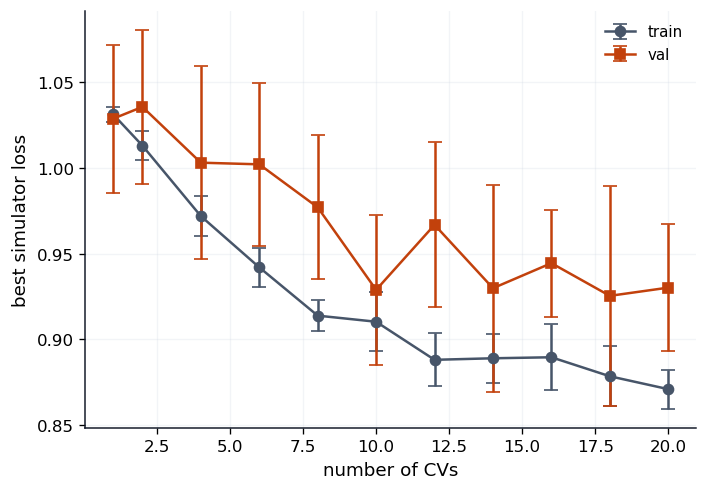

CV-count sweep: downstream linear-combo R2 versus number of CVs


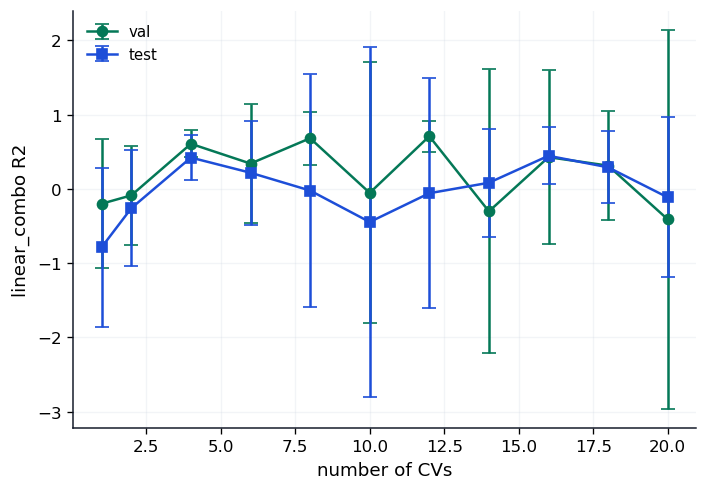

CV-count sweep: downstream linear-combo RMSE versus number of CVs


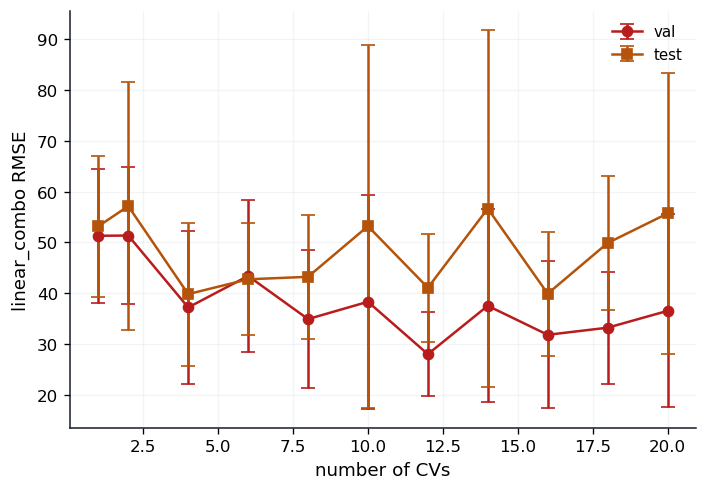

saved: ../results/chignolin_cv_tm_2stage_cvcount_sweep/cv_count_sweep_runs.csv
saved: ../results/chignolin_cv_tm_2stage_cvcount_sweep/cv_count_sweep_summary.csv


In [14]:
cv_sweep_force_train = False
cv_sweep_counts = [1, 2] + list(range(4, 21, 2))
cv_sweep_runs_per_cv = 10
cv_sweep_metric_name = 'Tm'
cv_sweep_max_combo_size = 6
cv_sweep_output_root = Path('../results/chignolin_cv_tm_2stage_cvcount_sweep')
cv_sweep_output_root.mkdir(parents=True, exist_ok=True)


def fit_linear_combo_decoder_limited(train_df, val_df, test_df, metric_name, max_combo_size=5):
    cv_cols = [c for c in train_df.columns if c.startswith('cv_')]
    best_result = None
    max_subset = min(len(cv_cols), int(max_combo_size))
    for subset_size in range(1, max_subset + 1):
        for subset in itertools.combinations(cv_cols, subset_size):
            subset = list(subset)
            coef = fit_linear_coefficients(train_df, subset, metric_name)
            train_pred_df = predict_linear_df(train_df, subset, coef, metric_name)
            val_pred_df = predict_linear_df(val_df, subset, coef, metric_name)
            test_pred_df = predict_linear_df(test_df, subset, coef, metric_name)
            result = {
                'decoder': 'linear_combo',
                'decoder_detail': ' + '.join(subset),
                'feature_cols': subset,
                'coef': coef.tolist(),
                'train_pred_df': train_pred_df,
                'val_pred_df': val_pred_df,
                'test_pred_df': test_pred_df,
                'train_stats': prediction_stats(train_pred_df, metric_name),
                'val_stats': prediction_stats(val_pred_df, metric_name),
                'test_stats': prediction_stats(test_pred_df, metric_name),
            }
            if best_result is None or (abs(result['val_stats']['pearson']), -result['val_stats']['rmse'], -result['val_stats']['mae']) > (abs(best_result['val_stats']['pearson']), -best_result['val_stats']['rmse'], -best_result['val_stats']['mae']):
                best_result = result
    return best_result


def run_cvcount_trial(cv_count, run_idx, metric_name='Tm'):
    trial_seed = 4000 * int(cv_count) + int(run_idx)
    trial_token_sizes = (int(token_sizes[0]), max(int(token_sizes[1]), int(cv_count)), int(cv_count))
    trial_dir = cv_sweep_output_root / f'cvcount_{cv_count:02d}_run_{run_idx:02d}'
    trial_dir.mkdir(parents=True, exist_ok=True)
    sim_history_csv = trial_dir / 'sim_history.csv'
    summary_json = trial_dir / 'summary.json'
    backbone_ckpt = trial_dir / 'backbone.pt'

    if (not cv_sweep_force_train) and sim_history_csv.exists() and summary_json.exists() and backbone_ckpt.exists():
        print(f"[reuse] CVs={cv_count:02d} run={run_idx:02d} | {trial_dir}", flush=True)
        sim_history_df = pd.read_csv(sim_history_csv)
        summary = json.loads(summary_json.read_text())
        return sim_history_df, summary

    print(f"[train] CVs={cv_count:02d} run={run_idx:02d} | seed={trial_seed} | token_sizes={trial_token_sizes}", flush=True)
    random.seed(trial_seed)
    np.random.seed(trial_seed)
    torch.manual_seed(trial_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(trial_seed)

    split_payload = build_train_val_test_split(
        run_seed=trial_seed,
        uniq_mutants=uniq_mutants,
        train_mutant_count=train_mutant_count,
        val_mutant_count=val_mutant_count,
        mutants=mutants,
        history=history,
        time_lag_steps=time_lag_steps,
        frames_per_traj=frames_per_traj,
        take_every_kth_frame=take_every_kth_frame,
        x_all=x_all,
        time_all=time_all,
        offsets=offsets,
        labels=labels,
        n_feat=n_feat,
    )

    release_cuda_memory()
    backbone = BackboneModel(
        feat_dim=n_feat,
        history=history,
        hidden=hidden_size,
        token_sizes=trial_token_sizes,
        heads=heads,
        token_layers=transformer_layers,
        dropout=dropout,
        pre_pyramid_layers=pre_pyramid_layers,
        linear_cv_decoder=linear_cv_decoder,
    ).to(device)
    sim_opt = torch.optim.AdamW(backbone.parameters(), lr=sim_learning_rate, weight_decay=weight_decay)
    train_loader = DataLoader(
        TensorDataset(split_payload['train_x'], split_payload['train_dv'], split_payload['train_dv_tau'], split_payload['train_cls']),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )
    val_loader = DataLoader(
        TensorDataset(split_payload['val_x'], split_payload['val_dv'], split_payload['val_dv_tau'], split_payload['val_cls']),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )

    sim_history_rows = []
    best_sim_loss = float('inf')
    best_sim_epoch = 0
    sim_bad_epochs = 0
    for epoch in range(1, sim_epochs + 1):
        tr = run_sim_epoch(backbone, train_loader, device=device, time_lag_steps=time_lag_steps, time_lag_weight=time_lag_weight, cls_weight=cls_weight, opt=sim_opt)
        va = run_sim_epoch(backbone, val_loader, device=device, time_lag_steps=time_lag_steps, time_lag_weight=time_lag_weight, cls_weight=cls_weight, opt=None)
        sim_history_rows.append({
            'CVs': int(cv_count),
            'run_idx': int(run_idx),
            'run_seed': int(trial_seed),
            'epoch': int(epoch),
            **{f'train_{k}': v for k, v in tr.items()},
            **{f'val_{k}': v for k, v in va.items()},
        })
        if va['sim_loss'] < best_sim_loss - 1e-8:
            best_sim_loss = float(va['sim_loss'])
            best_sim_epoch = int(epoch)
            sim_bad_epochs = 0
            torch.save({'run_seed': trial_seed, 'epoch': epoch, 'model_state_dict': backbone.state_dict()}, backbone_ckpt)
        else:
            sim_bad_epochs += 1
        if sim_bad_epochs >= sim_early_stop_patience:
            break

    sim_history_df = pd.DataFrame(sim_history_rows)
    sim_history_df.to_csv(sim_history_csv, index=False)

    backbone.load_state_dict(torch.load(backbone_ckpt, map_location='cpu', weights_only=False)['model_state_dict'])
    backbone.eval()
    train_cv_sequences = extract_cv_sequences(backbone, split_payload['train_x'], split_payload['train_samples_df'], batch_size=batch_size, device=device)
    val_cv_sequences = extract_cv_sequences(backbone, split_payload['val_x'], split_payload['val_samples_df'], batch_size=batch_size, device=device)
    test_cv_sequences = extract_cv_sequences(backbone, split_payload['test_x'], split_payload['test_samples_df'], batch_size=batch_size, device=device)

    metric_stats = metric_stats_from_train_mutants(split_payload['train_mutants'], target_df, metric_name)
    train_metric_dataset = build_metric_dataset(train_cv_sequences, metric_stats, target_df, metric_name)
    val_metric_dataset = build_metric_dataset(val_cv_sequences, metric_stats, target_df, metric_name)
    test_metric_dataset = build_metric_dataset(test_cv_sequences, metric_stats, target_df, metric_name)
    train_pooled_df = build_pooled_feature_df(train_metric_dataset, metric_name)
    val_pooled_df = build_pooled_feature_df(val_metric_dataset, metric_name)
    test_pooled_df = build_pooled_feature_df(test_metric_dataset, metric_name)
    single_result = fit_best_single_cv_decoder(train_pooled_df, val_pooled_df, test_pooled_df, metric_name)
    combo_result = fit_linear_combo_decoder_limited(train_pooled_df, val_pooled_df, test_pooled_df, metric_name, max_combo_size=cv_sweep_max_combo_size)

    summary = {
        'CVs': int(cv_count),
        'run_idx': int(run_idx),
        'seed': int(trial_seed),
        'token_sizes': list(trial_token_sizes),
        'max_combo_size': int(cv_sweep_max_combo_size),
        'best_train_sim_loss': float(sim_history_df['train_sim_loss'].min()),
        'best_val_sim_loss': float(sim_history_df['val_sim_loss'].min()),
        'best_sim_epoch': int(best_sim_epoch),
        'single_cv_detail': str(single_result['decoder_detail']),
        'single_cv_val_r2': float(single_result['val_stats']['r2']),
        'single_cv_test_r2': float(single_result['test_stats']['r2']),
        'single_cv_val_rmse': float(single_result['val_stats']['rmse']),
        'single_cv_test_rmse': float(single_result['test_stats']['rmse']),
        'linear_combo_detail': str(combo_result['decoder_detail']),
        'linear_combo_val_r2': float(combo_result['val_stats']['r2']),
        'linear_combo_test_r2': float(combo_result['test_stats']['r2']),
        'linear_combo_val_rmse': float(combo_result['val_stats']['rmse']),
        'linear_combo_test_rmse': float(combo_result['test_stats']['rmse']),
        'linear_combo_val_pearson': float(combo_result['val_stats']['pearson']),
        'linear_combo_test_pearson': float(combo_result['test_stats']['pearson']),
    }
    summary_json.write_text(json.dumps(summary, indent=2))
    print(
        f"[done] CVs={cv_count:02d} run={run_idx:02d} | best val sim={summary['best_val_sim_loss']:.4f} | "
        f"test r={summary['linear_combo_test_pearson']:.4f} | test rmse={summary['linear_combo_test_rmse']:.4f}",
        flush=True,
    )
    release_cuda_memory()
    return sim_history_df, summary


cv_sweep_rows = []
for cv_count in cv_sweep_counts:
    for run_idx in range(1, cv_sweep_runs_per_cv + 1):
        _, trial_summary = run_cvcount_trial(cv_count, run_idx, metric_name=cv_sweep_metric_name)
        cv_sweep_rows.append(trial_summary)

cvcount_sweep_df = pd.DataFrame(cv_sweep_rows).sort_values(['CVs', 'run_idx']).reset_index(drop=True)
cvcount_sweep_summary_df = cvcount_sweep_df.groupby('CVs', as_index=False).agg(
    mean_best_train_sim_loss=('best_train_sim_loss', 'mean'),
    std_best_train_sim_loss=('best_train_sim_loss', 'std'),
    mean_best_val_sim_loss=('best_val_sim_loss', 'mean'),
    std_best_val_sim_loss=('best_val_sim_loss', 'std'),
    mean_linear_combo_val_r2=('linear_combo_val_r2', 'mean'),
    std_linear_combo_val_r2=('linear_combo_val_r2', 'std'),
    mean_linear_combo_test_r2=('linear_combo_test_r2', 'mean'),
    std_linear_combo_test_r2=('linear_combo_test_r2', 'std'),
    mean_linear_combo_val_rmse=('linear_combo_val_rmse', 'mean'),
    std_linear_combo_val_rmse=('linear_combo_val_rmse', 'std'),
    mean_linear_combo_test_rmse=('linear_combo_test_rmse', 'mean'),
    std_linear_combo_test_rmse=('linear_combo_test_rmse', 'std'),
)

display(cvcount_sweep_df.round(4))
display(cvcount_sweep_summary_df.round(4))

paper_caption('CV-count sweep: stage-1 simulator loss versus number of CVs')
fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.2))
ax.errorbar(cvcount_sweep_summary_df['CVs'], cvcount_sweep_summary_df['mean_best_train_sim_loss'], yerr=cvcount_sweep_summary_df['std_best_train_sim_loss'].fillna(0.0), fmt='o-', capsize=4, label='train', color=PAPER_COLORS['slate'])
ax.errorbar(cvcount_sweep_summary_df['CVs'], cvcount_sweep_summary_df['mean_best_val_sim_loss'], yerr=cvcount_sweep_summary_df['std_best_val_sim_loss'].fillna(0.0), fmt='s-', capsize=4, label='val', color=PAPER_COLORS['orange'])
style_axes(ax, xlabel='number of CVs', ylabel='best simulator loss', legend=True)
plt.tight_layout()
plt.show()

paper_caption('CV-count sweep: downstream linear-combo R2 versus number of CVs')
fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.2))
ax.errorbar(cvcount_sweep_summary_df['CVs'], cvcount_sweep_summary_df['mean_linear_combo_val_r2'], yerr=cvcount_sweep_summary_df['std_linear_combo_val_r2'].fillna(0.0), fmt='o-', capsize=4, label='val', color=PAPER_COLORS['green'])
ax.errorbar(cvcount_sweep_summary_df['CVs'], cvcount_sweep_summary_df['mean_linear_combo_test_r2'], yerr=cvcount_sweep_summary_df['std_linear_combo_test_r2'].fillna(0.0), fmt='s-', capsize=4, label='test', color=PAPER_COLORS['blue'])
style_axes(ax, xlabel='number of CVs', ylabel='linear_combo R2', legend=True)
plt.tight_layout()
plt.show()

paper_caption('CV-count sweep: downstream linear-combo RMSE versus number of CVs')
fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.2))
ax.errorbar(cvcount_sweep_summary_df['CVs'], cvcount_sweep_summary_df['mean_linear_combo_val_rmse'], yerr=cvcount_sweep_summary_df['std_linear_combo_val_rmse'].fillna(0.0), fmt='o-', capsize=4, label='val', color=PAPER_COLORS['red'])
ax.errorbar(cvcount_sweep_summary_df['CVs'], cvcount_sweep_summary_df['mean_linear_combo_test_rmse'], yerr=cvcount_sweep_summary_df['std_linear_combo_test_rmse'].fillna(0.0), fmt='s-', capsize=4, label='test', color=PAPER_COLORS['gold'])
style_axes(ax, xlabel='number of CVs', ylabel='linear_combo RMSE', legend=True)
plt.tight_layout()
plt.show()

cvcount_sweep_df.to_csv(cv_sweep_output_root / 'cv_count_sweep_runs.csv', index=False)
cvcount_sweep_summary_df.to_csv(cv_sweep_output_root / 'cv_count_sweep_summary.csv', index=False)
print('saved:', cv_sweep_output_root / 'cv_count_sweep_runs.csv')
print('saved:', cv_sweep_output_root / 'cv_count_sweep_summary.csv')
